# Grid Search On Novel Dataset

We are switching the dataset that we are using from the may 30th dataset to the identical but larger 

# Package Imports

In [17]:
# Basic Package Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import mean_squared_error, r2_score

# imblearn
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Non-basic package imports
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import requests

# Packages I don't understand
import os 
from fcd_torch import FCD
import rdkit
from collections import Counter
import gc
import pickle

# Packages I made
import functions_enc as f
import function_depot as fd

# Data Processing

In [2]:
# We are switching to the June 25 dataset
df4 = pd.read_csv("/home/dlipsey/MITLincolnLabs/MIT_LL_data/MIT_LL_data4.csv")
print(df4.shape)
df4.head()

# Uniformity of ionization model labels
print(df4["Ionization_Mode"].unique())
df4["Ionization_Mode"] = df4["Ionization_Mode"].replace("'Positive'", "'positive'")
print(df4["Ionization_Mode"].unique())
# Remove the N/A values in Ionization_Mode
df4 = df4[df4["Ionization_Mode"] != "'N/A'"]
print(df4["Ionization_Mode"].unique())

# Remove single quotes from all string columns in df4
df4 = df4.applymap(lambda x: x.replace("'", "") if isinstance(x, str) else x)

# print(df4['Group'].nunique()) # 12
# # 12 groups
# print(df4['Group'].unique())
# # Now we want counts of each group
# print(df4['Group'].value_counts())

# This will give us the subsets with all of the relevant information
df4_QQpos = df4[df4['Group'] == 'Q-Orbitrap-positive'] # 2065

# Other groups with their sizes listed
# df4_QQneg = df4[df4['Group'] == 'Q-Orbitrap-negative'] # 1400
# df4_QTOFpos = df4[df4['Group'] == 'Q-TOF-positive'] # 1098
# df4_LTQOpos = df4[df4['Group'] == 'LTQ-Orbitrap-positive'] # 615

# All of the other are just too small to be all that useful with sizes from 12 to 286 associated spectra

df4_QQpos.head()


(6121, 16)
["'positive'" "'negative'" "'Positive'" "'N/A'"]
["'positive'" "'negative'" "'N/A'"]
["'positive'" "'negative'"]


,SMILES_spectra,CAS,Molecular_Formula,Total_Exact_Mass,Precursor_m/z,Precursor_Type,Spectrum,Ionization_Mode,Instrument_Type,Instrument_Name,Collision_Energy,SMILES_tox_vals,Response_Modifier,Response,Response_Unit,Group
0,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,63.0228:0.177223 65.0386:5.629055 68.0495:0.45...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,90 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive
1,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,63.0228:0.125979 65.0386:2.113734 68.0495:0.68...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,75 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive
2,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,56.0496:0.115017 65.0386:0.970445 68.0495:1.03...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,60 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive
3,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,51.0229:0.102992 56.0495:0.143820 65.0386:0.67...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,45 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive
4,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,56.0496:0.482623 65.0385:0.377829 68.0495:2.59...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,30 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive


In [3]:
# Save df4_QQpos as a CSV file
df4_QQpos.to_csv("/home/dlipsey/MITLincolnLabs/MIT_LL_data/df4_QQpos.csv", index=False)

In [4]:
df4_QQpos['index_id'] = range(len(df4_QQpos))
# Apply the function - it now handles all the processing internally
df4_QQpos_spectra = fd.spectrum_string_to_dataframe(df4_QQpos, "Spectrum", "SMILES_spectra")

/tmp/ipykernel_2621519/1899713419.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df4_QQpos['index_id'] = range(len(df4_QQpos))


In [5]:
df4_QQpos_spectra.head()

,SMILES_spectra,50.005653,50.011404,50.013491,50.015,50.0151,50.0152,50.0153,50.0156,50.030101,...,531.1562,531.1565,531.1568,540.3537,555.3646,555.3654,603.3863,661.428,679.4382,index_id
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
4,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


In [6]:
df4_QQpos.head()

,SMILES_spectra,CAS,Molecular_Formula,Total_Exact_Mass,Precursor_m/z,Precursor_Type,Spectrum,Ionization_Mode,Instrument_Type,Instrument_Name,Collision_Energy,SMILES_tox_vals,Response_Modifier,Response,Response_Unit,Group,index_id
0,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,63.0228:0.177223 65.0386:5.629055 68.0495:0.45...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,90 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive,0
1,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,63.0228:0.125979 65.0386:2.113734 68.0495:0.68...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,75 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive,1
2,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,56.0496:0.115017 65.0386:0.970445 68.0495:1.03...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,60 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive,2
3,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,51.0229:0.102992 56.0495:0.143820 65.0386:0.67...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,45 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive,3
4,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,56.0496:0.482623 65.0385:0.377829 68.0495:2.59...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,30 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive,4


# Binning

In [7]:
# Define your parameters
bin_sizes = [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]
thresholds = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
save_directory = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes"

# Create all datasets
# all_datasets = fd.binning_loop(df4_QQpos_spectra, df4_QQpos, bin_sizes, thresholds, save_directory)

# Spectra Random Forest Training

In [8]:
# Load datasets folder path
grid_search_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes"

# Get all .pkl files in the folder
pkl_files = [f for f in os.listdir(grid_search_folder) if f.endswith('.pkl')]
dataset_names = [f.replace('.pkl', '') for f in pkl_files]

print(f"Found {len(dataset_names)} datasets to process")
print(f"Expected: 182 datasets")

# Verify we have the right count
thresh0_datasets = [name for name in dataset_names if 'thresh_zero' in name]
thresholded_datasets = [name for name in dataset_names if 'thresh_zero' not in name]

print(f"  - Datasets with thresh0 (no threshold): {len(thresh0_datasets)}")
print(f"  - Datasets with thresholds applied: {len(thresholded_datasets)}")

# Initialize storage for results
results_r2 = []
results_percent_error = []

# Dictionary to store individual errors for histogram analysis
saved_spectral_errors = {}

# Process datasets ONE AT A TIME (memory efficient)
for i, dataset_name in enumerate(sorted(dataset_names), 1):
    print(f"Processing {i}/{len(dataset_names)}: {dataset_name}")
    
    try:
        # Load only the current dataset
        file_path = os.path.join(grid_search_folder, f"{dataset_name}.pkl")
        df = pd.read_pickle(file_path)
        
        # Prepare features and target
        feature_cols = [col for col in df.columns if col not in ['SMILES_spectra', 'Response', 'log_response', 'index_id']]
        X = df[feature_cols]
        y = df['log_response']
        
        # Remove rows with NaN values
        valid_mask = ~(X.isna().any(axis=1) | y.isna())
        X_clean = X[valid_mask]
        y_clean = y[valid_mask]
        
        if len(X_clean) < 10:  # Skip if too few samples
            print(f"  Skipping {dataset_name}: Only {len(X_clean)} valid samples")
            continue
            
        # Split the data
        X_train, X_test, y_train, y_test = train_test_split(
            X_clean, y_clean, test_size=0.5, random_state=42
        )
        
        # Train Random Forest with limited CPU usage
        rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=2)
        rf.fit(X_train, y_train)
        
        # Make predictions
        y_train_pred = rf.predict(X_train)
        y_test_pred = rf.predict(X_test)
        
        # Calculate R² metrics
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        # Calculate absolute percent error (undo log transform first)
        y_train_true_response = np.exp(y_train)
        y_train_pred_response = np.exp(y_train_pred)
        y_test_true_response = np.exp(y_test)
        y_test_pred_response = np.exp(y_test_pred)
        
        # Calculate individual errors for test set
        individual_errors = np.abs((y_test_pred_response - y_test_true_response) / y_test_true_response) * 100
        
        # Save individual errors for histogram analysis
        saved_spectral_errors[dataset_name] = individual_errors
        
        # Calculate median and mean absolute percent error
        train_median_percent_error = 100 * (np.median(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_median_percent_error = 100 * (np.median(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))
        train_mean_percent_error = 100 * (np.mean(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_mean_percent_error = 100 * (np.mean(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))

        # Store results
        results_r2.append({
            'Dataset': dataset_name,
            'Train_R2': train_r2,
            'Test_R2': test_r2,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        results_percent_error.append({
            'Dataset': dataset_name,
            'Train_Median_Percent_Error': train_median_percent_error,
            'Test_Median_Percent_Error': test_median_percent_error,
            'Train_Mean_Percent_Error': train_mean_percent_error,
            'Test_Mean_Percent_Error': test_mean_percent_error,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        print(f"Completed: Test R² = {test_r2:.4f}, Test Median % Error = {test_median_percent_error:.1f}%")
        
    except Exception as e:
        print(f"Error processing {dataset_name}: {str(e)}")
        continue
    
    finally:
        # Always clean up memory after each dataset
        if 'df' in locals():
            del df
        if 'X' in locals():
            del X, y, X_clean, y_clean
        if 'rf' in locals():
            del rf
        gc.collect()
        
        # Periodic deeper cleanup every 20 datasets
        if i % 20 == 0:
            print(f"  Deep cleanup after {i} datasets...")
            gc.collect()

# Convert results to DataFrames
df_r2_results = pd.DataFrame(results_r2)
df_percent_error_results = pd.DataFrame(results_percent_error)

print(f"\nCompleted! Processed {len(results_r2)} datasets successfully.")
print(f"Saved individual errors for {len(saved_spectral_errors)} datasets")
print(f"Results stored in: df_r2_results, df_percent_error_results")

Found 182 datasets to process
Expected: 182 datasets
  - Datasets with thresh0 (no threshold): 14
  - Datasets with thresholds applied: 168
Processing 1/182: bin0_01_thresh0_001_df_spectra


Completed: Test R² = 0.4912, Test Median % Error = 40.2%
Processing 2/182: bin0_01_thresh0_005_df_spectra
Completed: Test R² = 0.4873, Test Median % Error = 40.8%
Processing 3/182: bin0_01_thresh0_01_df_spectra
Completed: Test R² = 0.4886, Test Median % Error = 41.3%
Processing 4/182: bin0_01_thresh0_05_df_spectra
Completed: Test R² = 0.4894, Test Median % Error = 41.2%
Processing 5/182: bin0_01_thresh0_1_df_spectra
Completed: Test R² = 0.4899, Test Median % Error = 41.4%
Processing 6/182: bin0_01_thresh0_5_df_spectra
Completed: Test R² = 0.4744, Test Median % Error = 42.2%
Processing 7/182: bin0_01_thresh100_df_spectra
Completed: Test R² = -0.0004, Test Median % Error = 68.4%
Processing 8/182: bin0_01_thresh10_df_spectra
Completed: Test R² = 0.3922, Test Median % Error = 43.6%
Processing 9/182: bin0_01_thresh1_df_spectra
Completed: Test R² = 0.4607, Test Median % Error = 42.4%
Processing 10/182: bin0_01_thresh2_df_spectra
Completed: Test R² = 0.4371, Test Median % Error = 42.9%
Proces

# Spectra Heatmap

Checking for duplicates in results...
Original df_r2_results shape: (182, 7)
After removing duplicates: (182, 7)
Creating detailed heatmaps...


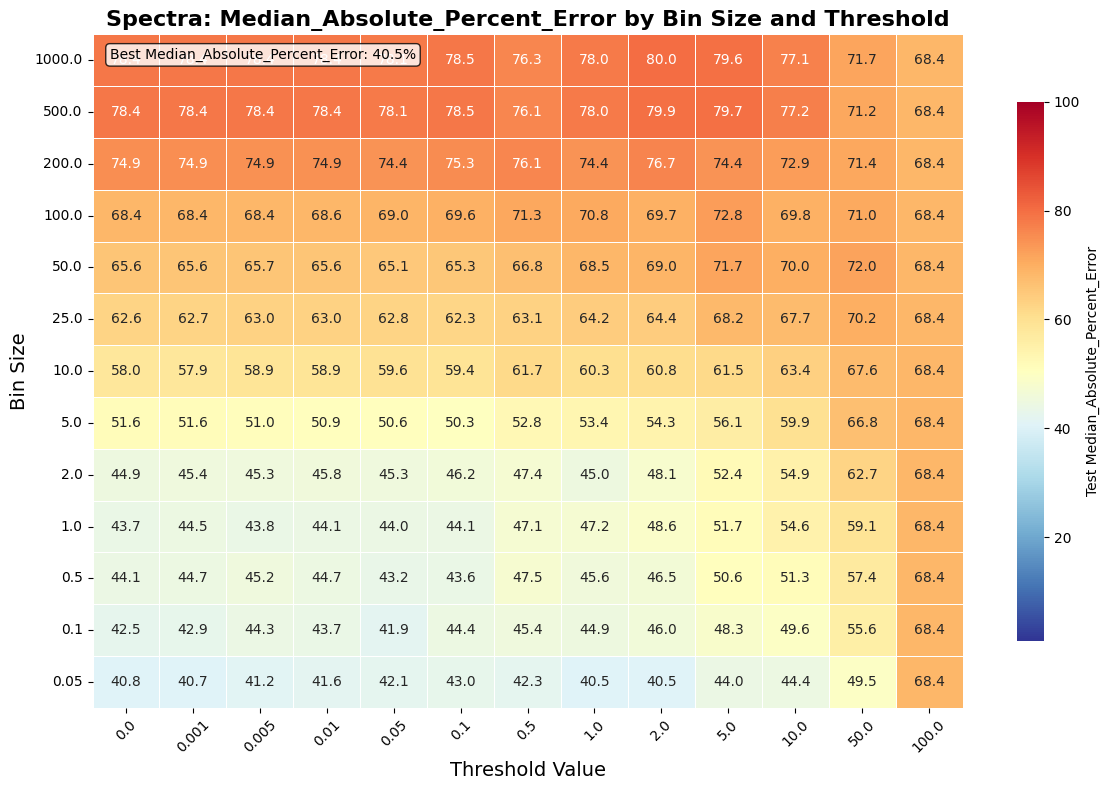

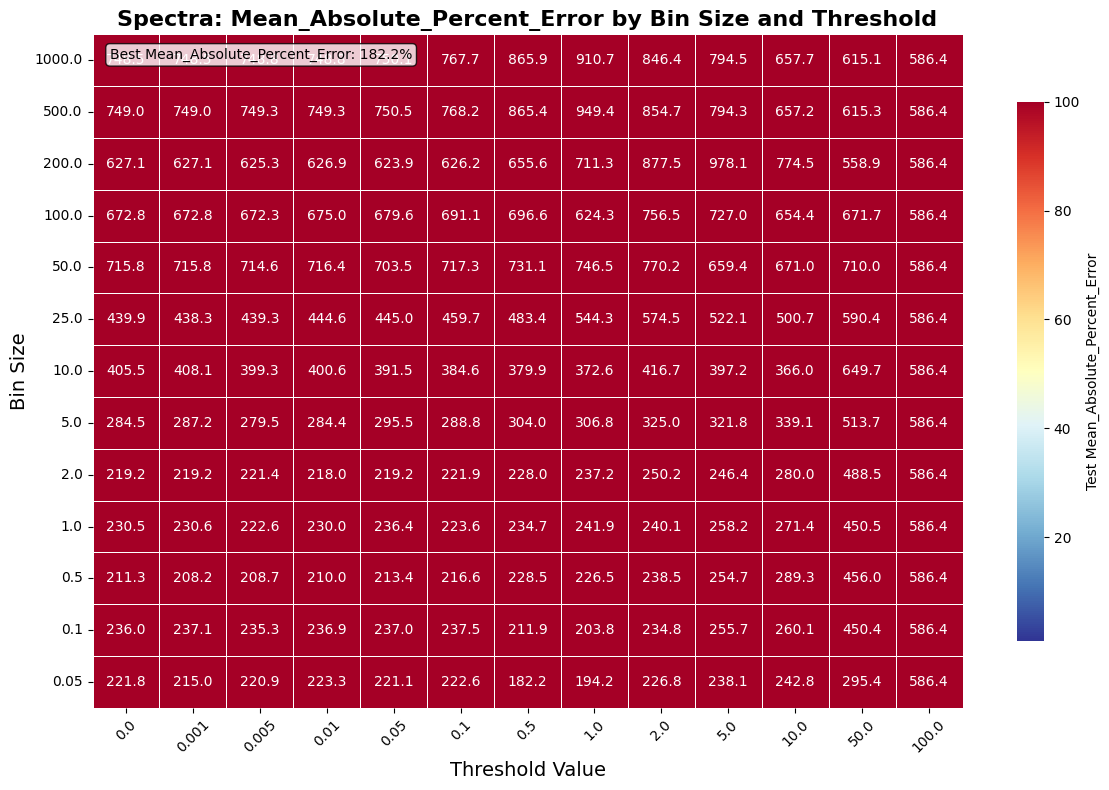

In [9]:
# Create the actual heatmaps for visualization
# First, let's extract bin size and threshold from the dataset names and add to results
def parse_dataset_name(dataset_name):
    """Extract bin size and threshold from dataset name"""
    # Handle thresh_zero case (no threshold)
    if 'thresh_zero' in dataset_name:
        # Extract bin size
        bin_part = dataset_name.split('_thresh_zero')[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        threshold = 0.0
    else:
        # Extract bin size and threshold
        parts = dataset_name.split('_thresh')
        bin_part = parts[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        
        thresh_part = parts[1].split('_df_spectra')[0]
        threshold = float(thresh_part.replace('_', '.'))
    
    return bin_size, threshold

# Add bin_size and threshold columns to results DataFrames
for df_results in [df_r2_results, df_percent_error_results]:
    bin_sizes = []
    thresholds = []
    
    for dataset_name in df_results['Dataset']:
        bin_size, threshold = parse_dataset_name(dataset_name)
        bin_sizes.append(bin_size)
        thresholds.append(threshold)
    
    df_results['BinSize'] = bin_sizes
    df_results['Threshold'] = thresholds

# Check for and remove duplicates before creating pivot tables
print("Checking for duplicates in results...")
print(f"Original df_r2_results shape: {df_r2_results.shape}")

# Remove duplicates based on BinSize + Threshold combination (keep first occurrence)
df_r2_results = df_r2_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')
df_percent_error_results = df_percent_error_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')

print(f"After removing duplicates: {df_r2_results.shape}")

# Now create pivot tables 
r2_pivot = df_r2_results.pivot(index='BinSize', columns='Threshold', values='Test_R2') 
median_percent_error_pivot = df_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Test_Median_Percent_Error')
mean_percent_error_pivot = df_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Test_Mean_Percent_Error')

# List all expected thresholds
thresholds_subset = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
bins_subset = [0.05, 0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]

# Reindex pivot tables to show all columns, filling missing with NaN
r2_pivot = r2_pivot.reindex(columns=thresholds_subset, index=bins_subset)
median_percent_error_pivot = median_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)
mean_percent_error_pivot = mean_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)

# Also create individual larger heatmaps for better detail
def create_detailed_heatmap_spec(pivot_data, metric_name, cmap, figsize=(12, 8), vmin=None, vmax=None):
    """Create a detailed heatmap for a single metric"""
    plt.figure(figsize=figsize)
    
    # Create heatmap
    sns.heatmap(pivot_data, 
                annot=True, 
                fmt='.3f' if 'R²' in metric_name else '.1f', 
                cmap=cmap,
                square=False,
                linewidths=0.5,
                vmin=vmin,
                vmax=vmax,
                cbar_kws={'label': f'Test {metric_name}', 'shrink': 0.8})
    
    plt.title(f'Spectra: {metric_name} by Bin Size and Threshold', fontsize=16, fontweight='bold')
    plt.xlabel('Threshold Value', fontsize=14)
    plt.ylabel('Bin Size', fontsize=14)
    plt.gca().invert_yaxis()
    
    # Improve readability
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # Add text annotation for best performance
    if 'R²' in metric_name:
        best_val = pivot_data.max().max()
        plt.text(0.02, 0.98, f'Best R²: {best_val:.4f}', 
                transform=plt.gca().transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                verticalalignment='top')
    else:
        best_val = pivot_data.min().min()
        plt.text(0.02, 0.98, f'Best {metric_name}: {best_val:.1f}%', 
                transform=plt.gca().transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                verticalalignment='top')
    
    plt.tight_layout()
    plt.savefig(f"/home/dlipsey/MITLincolnLabs/Figures/Spectra_{metric_name}_by_Bin_Size_and_Threshold")
    plt.show()

# Create detailed individual heatmaps
print("Creating detailed heatmaps...")

# create_detailed_heatmap_spec(r2_pivot, 'R²', 'RdYlBu')     
create_detailed_heatmap_spec(median_percent_error_pivot, 'Median_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0) 
create_detailed_heatmap_spec(mean_percent_error_pivot, 'Mean_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0)

# ChemNet Training

In [10]:
# # Redefine the fuction so it makes a list rather than a dictionary, Done to get dataset
# def get_chemnet_emb_from_smiles_list(smiles_list):
#     """
#     Get ChemNet embeddings for a list of SMILES strings, preserving order and duplicates.
#     Returns a list of embeddings (or 'unknown') in the same order as input.
#     """
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     fcd = FCD(device, n_jobs=1)
#     embeddings = []
#     for smiles in smiles_list:
#         try:
#             emb = fcd.get_predictions([smiles])[0]
#             embeddings.append(list(emb))
#         except KeyError as e:
#             if e == 'PropertyTable':
#                 embeddings.append('unknown')
#     return embeddings

# # For df4_QQpos mode - emulating the pattern from MIT_LL_first_encoder.ipynb
# smiles_list_df4_QQpos = df4_QQpos['SMILES_spectra'].tolist()
# embeddings_df4_QQpos = get_chemnet_emb_from_smiles_list(smiles_list_df4_QQpos)
# ChemNet_of_df4_QQpos = pd.DataFrame(embeddings_df4_QQpos)
# ChemNet_of_df4_QQpos.insert(0, 'SMILES_spectra', smiles_list_df4_QQpos)
# print(ChemNet_of_df4_QQpos.shape)  # Should be (2065, n_features+1)
# ChemNet_of_df4_QQpos.to_csv("/home/dlipsey/MITLincolnLabs/MIT_LL_data/ChemNet_of_df4_QQpos.csv", index=False)

In [11]:
# Load the pickle file
df_sample = pd.read_pickle("/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes/bin1000_thresh_zero_df_spectra.pkl")

# Print basic info
print(f"Shape: {df_sample.shape}")
print(f"Columns: {df_sample.columns.tolist()}")
print("\nFirst 5 rows:")
df_sample.head()

Shape: (2065, 5)
Columns: ['SMILES_spectra', 500.0, 'index_id', 'Response', 'log_response']

First 5 rows:


,SMILES_spectra,500.0,index_id,Response,log_response
0,C#CCN(C)Cc1ccccc1,108.140589,0,273.642508,5.611823
1,C#CCN(C)Cc1ccccc1,105.138766,1,273.642508,5.611823
2,C#CCN(C)Cc1ccccc1,105.775202,2,273.642508,5.611823
3,C#CCN(C)Cc1ccccc1,109.123517,3,273.642508,5.611823
4,C#CCN(C)Cc1ccccc1,134.727579,4,273.642508,5.611823


In [12]:
ChemNet_of_df4_QQpos = pd.read_csv("/home/dlipsey/MITLincolnLabs/MIT_LL_data/ChemNet_of_df4_QQpos.csv")
ChemNet_of_df4_QQpos.head()

,SMILES_spectra,0,1,2,3,4,5,6,7,8,...,502,503,504,505,506,507,508,509,510,511
0,C#CCN(C)Cc1ccccc1,-0.081878,-0.000592,-0.115424,0.361975,-0.013771,0.068946,-0.079094,-0.639643,-0.616823,...,0.120262,0.75748,0.757136,-0.000121,-0.201007,-0.281432,-0.574846,0.037261,0.048509,0.227904
1,C#CCN(C)Cc1ccccc1,-0.081878,-0.000592,-0.115424,0.361975,-0.013771,0.068946,-0.079094,-0.639643,-0.616823,...,0.120262,0.75748,0.757136,-0.000121,-0.201007,-0.281432,-0.574846,0.037261,0.048509,0.227904
2,C#CCN(C)Cc1ccccc1,-0.081878,-0.000592,-0.115424,0.361975,-0.013771,0.068946,-0.079094,-0.639643,-0.616823,...,0.120262,0.75748,0.757136,-0.000121,-0.201007,-0.281432,-0.574846,0.037261,0.048509,0.227904
3,C#CCN(C)Cc1ccccc1,-0.081878,-0.000592,-0.115424,0.361975,-0.013771,0.068946,-0.079094,-0.639643,-0.616823,...,0.120262,0.75748,0.757136,-0.000121,-0.201007,-0.281432,-0.574846,0.037261,0.048509,0.227904
4,C#CCN(C)Cc1ccccc1,-0.081878,-0.000592,-0.115424,0.361975,-0.013771,0.068946,-0.079094,-0.639643,-0.616823,...,0.120262,0.75748,0.757136,-0.000121,-0.201007,-0.281432,-0.574846,0.037261,0.048509,0.227904


In [13]:
# # Create folder for ChemNet datasets
# chemnet_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/chemnet_grid_search_dataframes"

# # ENCODER TRAINING LOOP - Process all datasets
# device = fd.set_up_gpu()
# name_smiles_embedding_df = pd.read_csv("/home/dlipsey/MITLincolnLabs/MIT_LL_data/ChemNet_of_df4_QQpos.csv")

# # Get all dataset files from the grid search folder
# grid_search_folder = "/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/grid_search_dataframes"
# dataset_files = [f for f in os.listdir(grid_search_folder) if f.endswith('.pkl') and 'df_spectra' in f]
# dataset_names = [f.replace('.pkl', '') for f in dataset_files]

# print(f"Found {len(dataset_names)} datasets to process")

# # Storage for encoder results
# encoder_results = []
# chemnet_datasets = {}

# # Training parameters
# batch_size = 64
# epochs=500
# lr=0.0001
# criterion=nn.MSELoss()
# output_size = 512
# num_layers = 8

# # Loop through each dataset
# for i, dataset_name in enumerate(sorted(dataset_names), 1):
#     print(f"\nProcessing {i}/{len(dataset_names)}: {dataset_name}")
    
#     try:
#         # Load dataset from pickle file
#         dataset_path = os.path.join(grid_search_folder, f"{dataset_name}.pkl")
#         current_dataset = pd.read_pickle(dataset_path)
        
#         print(f"Loaded {dataset_name} - Shape: {current_dataset.shape}")
        
#         # Fix data types
#         for col in current_dataset.columns:
#             if col not in ['SMILES_spectra', 'index_id']:
#                 current_dataset[col] = pd.to_numeric(current_dataset[col], errors='coerce').fillna(0.0)
#                 current_dataset[col] = current_dataset[col].astype(np.float32)
        
#         # Apply train/test split
#         counts = current_dataset['SMILES_spectra'].value_counts()
#         valid_smiles = counts[counts >= 4].index
#         filtered_dataset = current_dataset[current_dataset['SMILES_spectra'].isin(valid_smiles)].copy()
        
#         print(f"After filtering (>=4 spectra per SMILES): {filtered_dataset.shape}")
        
#         train_indices = []
#         test_indices = []
        
#         np.random.seed(42)
#         for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
#             idx = group.index.tolist()
#             n = len(idx)
#             np.random.shuffle(idx)
#             split = n // 2
#             test_idx = idx[:split]
#             train_idx = idx[split:]
#             train_indices.extend(train_idx)
#             test_indices.extend(test_idx)
        
#         train_data_current = filtered_dataset.loc[train_indices].reset_index(drop=True)
#         test_data_current = filtered_dataset.loc[test_indices].reset_index(drop=True)
#         train_data_current['index'] = train_data_current.index
#         test_data_current['index'] = test_data_current.index
        
#         print(f"Train data shape: {train_data_current.shape}")
#         print(f"Test data shape: {test_data_current.shape}")
        
#         # Create tensors
#         y_train_enc, x_train_enc, train_indices_tensor = fd.create_dataset_tensors(
#             train_data_current, name_smiles_embedding_df, device, start_idx=1, stop_idx=-3)
        
#         y_val_enc, x_val_enc, val_indices_tensor = fd.create_dataset_tensors(
#             test_data_current, name_smiles_embedding_df, device, start_idx=1, stop_idx=-3)
        
#         print(f"Training tensor shapes: x_train: {x_train_enc.shape}, y_train: {y_train_enc.shape}")
        
#         train_dataset = TensorDataset(x_train_enc, y_train_enc, train_indices_tensor)
#         val_dataset = TensorDataset(x_val_enc, y_val_enc, val_indices_tensor)
#         train_loader_enc = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
#         val_loader_enc = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        
#         # Create and train encoder
#         encoder_current = fd.Encoder(input_size=x_train_enc.shape[1], output_size=output_size, num_layers=num_layers).to(device)
        
#         # Train encoder (using your existing train_model_encoder function)
#         trained_encoder = fd.train_model_encoder(
#             model=encoder_current,
#             train_data=train_loader_enc,
#             val_data=val_loader_enc,
#             epochs=epochs,
#             learning_rate=lr,
#             criterion=criterion,
#             device=device
#         )
        
#         # Generate embeddings
#         encoder_current.eval()
#         with torch.no_grad():
#             train_embeddings = encoder_current(x_train_enc).cpu().numpy()
#             test_embeddings = encoder_current(x_val_enc).cpu().numpy()
        
#         print(f"Generated embeddings shapes: train: {train_embeddings.shape}, test: {test_embeddings.shape}")
        
#         # Create ChemNet dataset with embeddings
#         train_chemnet_df = pd.DataFrame(train_embeddings, columns=[f'emb_{j}' for j in range(output_size)])
#         train_chemnet_df['SMILES_spectra'] = train_data_current['SMILES_spectra'].values
#         train_chemnet_df['Response'] = train_data_current['Response'].values
#         train_chemnet_df['log_response'] = train_data_current['log_response'].values
#         train_chemnet_df['index_id'] = train_data_current['index_id'].values
        
#         test_chemnet_df = pd.DataFrame(test_embeddings, columns=[f'emb_{j}' for j in range(output_size)])
#         test_chemnet_df['SMILES_spectra'] = test_data_current['SMILES_spectra'].values
#         test_chemnet_df['Response'] = test_data_current['Response'].values
#         test_chemnet_df['log_response'] = test_data_current['log_response'].values
#         test_chemnet_df['index_id'] = test_data_current['index_id'].values
        
#         # Combine train and test
#         full_chemnet_df = pd.concat([train_chemnet_df, test_chemnet_df], ignore_index=True)
        
#         print(f"Final ChemNet dataset shape: {full_chemnet_df.shape}")
#         print(f"Columns: {full_chemnet_df.columns.tolist()}")
        
#         # Save to chemnet folder
#         chemnet_dataset_name = f"chemnet_emb_{dataset_name}"
#         save_path = os.path.join(chemnet_folder, f"{chemnet_dataset_name}.pkl")
#         full_chemnet_df.to_pickle(save_path)
#         print(f"Saved to: {save_path}")
        
#         # Store results
#         encoder_results.append({
#             'Original_Dataset': dataset_name,
#             'ChemNet_Dataset': chemnet_dataset_name,
#             'Train_Samples': len(train_data_current),
#             'Test_Samples': len(test_data_current),
#             'Total_Samples': len(full_chemnet_df),
#             'Embedding_Dim': output_size,
#             'Original_Features': x_train_enc.shape[1]
#         })
        
#         # Store in memory as well
#         chemnet_datasets[chemnet_dataset_name] = full_chemnet_df
        
#     except Exception as e:
#         print(f"Error processing {dataset_name}: {str(e)}")
#         continue

# print(f"\n=== ENCODER TRAINING COMPLETED ===")
# print(f"Successfully processed {len(encoder_results)} datasets")
# print(f"Created ChemNet embedding datasets saved to: {chemnet_folder}")

# # Display results summary
# results_df = pd.DataFrame(encoder_results)
# print("\nProcessing Summary:")
# print(results_df)

# ChemNet RF

In [14]:
import os
import gc
import pickle

# Load ChemNet datasets folder path
chemnet_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/chemnet_grid_search_dataframes"

# Get all .pkl files in the folder
chemnet_pkl_files = [f for f in os.listdir(chemnet_folder) if f.endswith('.pkl')]
chemnet_dataset_names = [f.replace('.pkl', '') for f in chemnet_pkl_files]

print(f"Found {len(chemnet_dataset_names)} ChemNet datasets to process")

# Verify we have the right count
chemnet_thresh0_datasets = [name for name in chemnet_dataset_names if 'thresh_zero' in name]
chemnet_thresholded_datasets = [name for name in chemnet_dataset_names if 'thresh_zero' not in name]

print(f"  - ChemNet datasets with thresh0 (no threshold): {len(chemnet_thresh0_datasets)}")
print(f"  - ChemNet datasets with thresholds applied: {len(chemnet_thresholded_datasets)}")

# Initialize storage for ChemNet results
chemnet_results_r2 = []
chemnet_results_percent_error = []

# Dictionary to store individual errors for histogram analysis
saved_chemnet_errors = {}

# Process ChemNet datasets ONE AT A TIME (memory efficient)
for i, dataset_name in enumerate(sorted(chemnet_dataset_names), 1):
    print(f"Processing {i}/{len(chemnet_dataset_names)}: {dataset_name}")
    
    try:
        # Load only the current ChemNet dataset
        file_path = os.path.join(chemnet_folder, f"{dataset_name}.pkl")
        df = pd.read_pickle(file_path)
        
        # Prepare features and target (embedding columns are the features)
        feature_cols = [col for col in df.columns if col.startswith('emb_')]
        X = df[feature_cols]
        y = df['log_response']
        
        # Remove rows with NaN values
        valid_mask = ~(X.isna().any(axis=1) | y.isna())
        X_clean = X[valid_mask]
        y_clean = y[valid_mask]
        
        if len(X_clean) < 10:  # Skip if too few samples
            print(f"  Skipping {dataset_name}: Only {len(X_clean)} valid samples")
            continue
            
        # Split the data
        X_train, X_test, y_train, y_test = train_test_split(
            X_clean, y_clean, test_size=0.5, random_state=47
        )
        
        # Train Random Forest with limited CPU usage
        rf_chemnet = RandomForestRegressor(n_estimators=100, random_state=47, n_jobs=2)
        rf_chemnet.fit(X_train, y_train)

        # Make predictions
        y_train_pred = rf_chemnet.predict(X_train)
        y_test_pred = rf_chemnet.predict(X_test)
        
        # Calculate R² metrics
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        # Calculate absolute percent error (undo log transform first)
        y_train_true_response = np.exp(y_train)
        y_train_pred_response = np.exp(y_train_pred)
        y_test_true_response = np.exp(y_test)
        y_test_pred_response = np.exp(y_test_pred)
        
        # Calculate individual errors for test set
        individual_errors = np.abs((y_test_pred_response - y_test_true_response) / y_test_true_response) * 100
        
        # Save individual errors for histogram analysis
        saved_chemnet_errors[dataset_name] = individual_errors
        
        # Calculate median and mean absolute percent error
        train_median_percent_error = 100 * (np.median(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_median_percent_error = 100 * (np.median(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))
        train_mean_percent_error = 100 * (np.mean(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_mean_percent_error = 100 * (np.mean(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))

        # Store results
        chemnet_results_r2.append({
            'Dataset': dataset_name,
            'Train_R2': train_r2,
            'Test_R2': test_r2,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        chemnet_results_percent_error.append({
            'Dataset': dataset_name,
            'Train_Median_Percent_Error': train_median_percent_error,
            'Test_Median_Percent_Error': test_median_percent_error,
            'Train_Mean_Percent_Error': train_mean_percent_error,
            'Test_Mean_Percent_Error': test_mean_percent_error,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        print(f"Completed: Test R² = {test_r2:.4f}, Test Median % Error = {test_median_percent_error:.1f}%")
        
    except Exception as e:
        print(f"Error processing {dataset_name}: {str(e)}")
        continue
    
    finally:
        # Always clean up memory after each dataset
        if 'df' in locals():
            del df
        if 'X' in locals():
            del X, y, X_clean, y_clean
        if 'rf_chemnet' in locals():
            del rf_chemnet
        gc.collect()
        
        # Periodic deeper cleanup every 20 datasets
        if i % 20 == 0:
            print(f"  Deep cleanup after {i} datasets...")
            gc.collect()

# Convert results to DataFrames
df_chemnet_r2_results = pd.DataFrame(chemnet_results_r2)
df_chemnet_percent_error_results = pd.DataFrame(chemnet_results_percent_error)

print(f"\nCompleted! Processed {len(chemnet_results_r2)} ChemNet datasets successfully.")
print(f"Saved individual errors for {len(saved_chemnet_errors)} datasets")
print(f"Results stored in: df_chemnet_r2_results, df_chemnet_percent_error_results")

# Display summary statistics
print("\n=== CHEMNET SUMMARY STATISTICS ===")
print("Test R² Statistics:")
print(df_chemnet_r2_results['Test_R2'].describe())

print("\nTest Median Percent Error Statistics:")
print(df_chemnet_percent_error_results['Test_Median_Percent_Error'].describe())

print("\nTest Mean Percent Error Statistics:")
print(df_chemnet_percent_error_results['Test_Mean_Percent_Error'].describe())

# Show top 10 performing ChemNet datasets by Test R²
print("\n=== TOP 10 CHEMNET DATASETS BY TEST R² ===")
top_chemnet_r2 = df_chemnet_r2_results.nlargest(10, 'Test_R2')[['Dataset', 'Test_R2', 'Features']]
print(top_chemnet_r2.to_string(index=False))

# Show comparison between thresh0 (no threshold) and thresholded ChemNet datasets
print("\n=== CHEMNET THRESH0 vs THRESHOLDED COMPARISON ===")
chemnet_thresh0_results = df_chemnet_r2_results[df_chemnet_r2_results['Dataset'].str.contains('thresh_zero')]
chemnet_thresholded_results = df_chemnet_r2_results[~df_chemnet_r2_results['Dataset'].str.contains('thresh_zero')]

if len(chemnet_thresh0_results) > 0:
    print(f"ChemNet thresh0 datasets (no threshold) - Mean Test R²: {chemnet_thresh0_results['Test_R2'].mean():.4f}")
    print(f"Best ChemNet thresh0 dataset: {chemnet_thresh0_results.loc[chemnet_thresh0_results['Test_R2'].idxmax(), 'Dataset']} (R² = {chemnet_thresh0_results['Test_R2'].max():.4f})")

if len(chemnet_thresholded_results) > 0:
    print(f"ChemNet thresholded datasets - Mean Test R²: {chemnet_thresholded_results['Test_R2'].mean():.4f}")
    print(f"Best ChemNet thresholded dataset: {chemnet_thresholded_results.loc[chemnet_thresholded_results['Test_R2'].idxmax(), 'Dataset']} (R² = {chemnet_thresholded_results['Test_R2'].max():.4f})")

Found 169 ChemNet datasets to process
  - ChemNet datasets with thresh0 (no threshold): 13
  - ChemNet datasets with thresholds applied: 156
Processing 1/169: chemnet_emb_bin0_05_thresh0_001_df_spectra


Completed: Test R² = 0.6821, Test Median % Error = 25.1%
Processing 2/169: chemnet_emb_bin0_05_thresh0_005_df_spectra
Completed: Test R² = 0.6920, Test Median % Error = 25.8%
Processing 3/169: chemnet_emb_bin0_05_thresh0_01_df_spectra
Completed: Test R² = 0.7304, Test Median % Error = 25.7%
Processing 4/169: chemnet_emb_bin0_05_thresh0_05_df_spectra
Completed: Test R² = 0.7407, Test Median % Error = 20.6%
Processing 5/169: chemnet_emb_bin0_05_thresh0_1_df_spectra
Completed: Test R² = 0.7182, Test Median % Error = 20.3%
Processing 6/169: chemnet_emb_bin0_05_thresh0_5_df_spectra
Completed: Test R² = 0.7297, Test Median % Error = 21.2%
Processing 7/169: chemnet_emb_bin0_05_thresh100_df_spectra
Completed: Test R² = -0.0030, Test Median % Error = 67.5%
Processing 8/169: chemnet_emb_bin0_05_thresh10_df_spectra
Completed: Test R² = 0.6505, Test Median % Error = 24.0%
Processing 9/169: chemnet_emb_bin0_05_thresh1_df_spectra
Completed: Test R² = 0.7028, Test Median % Error = 20.8%
Processing 10

# ChemNet Heatmap

Checking for duplicates in ChemNet results...
Original df_chemnet_r2_results shape: (169, 7)
After removing duplicates: (169, 7)
Creating detailed ChemNet heatmaps...


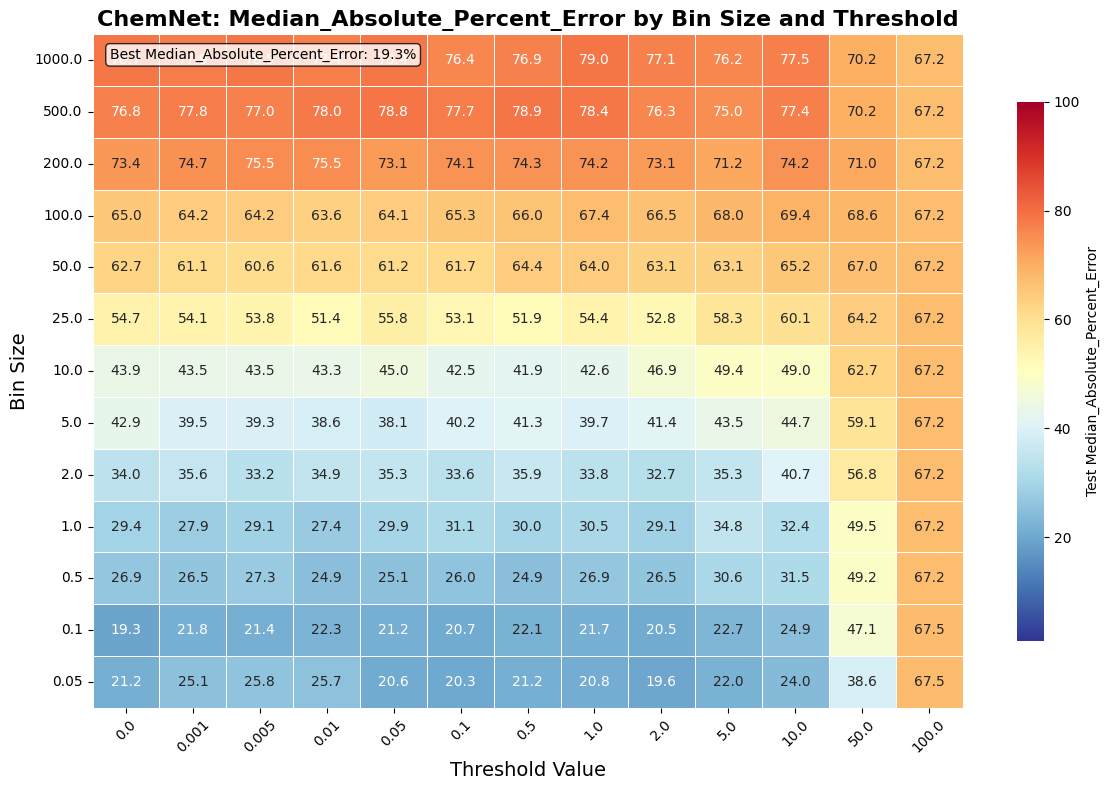

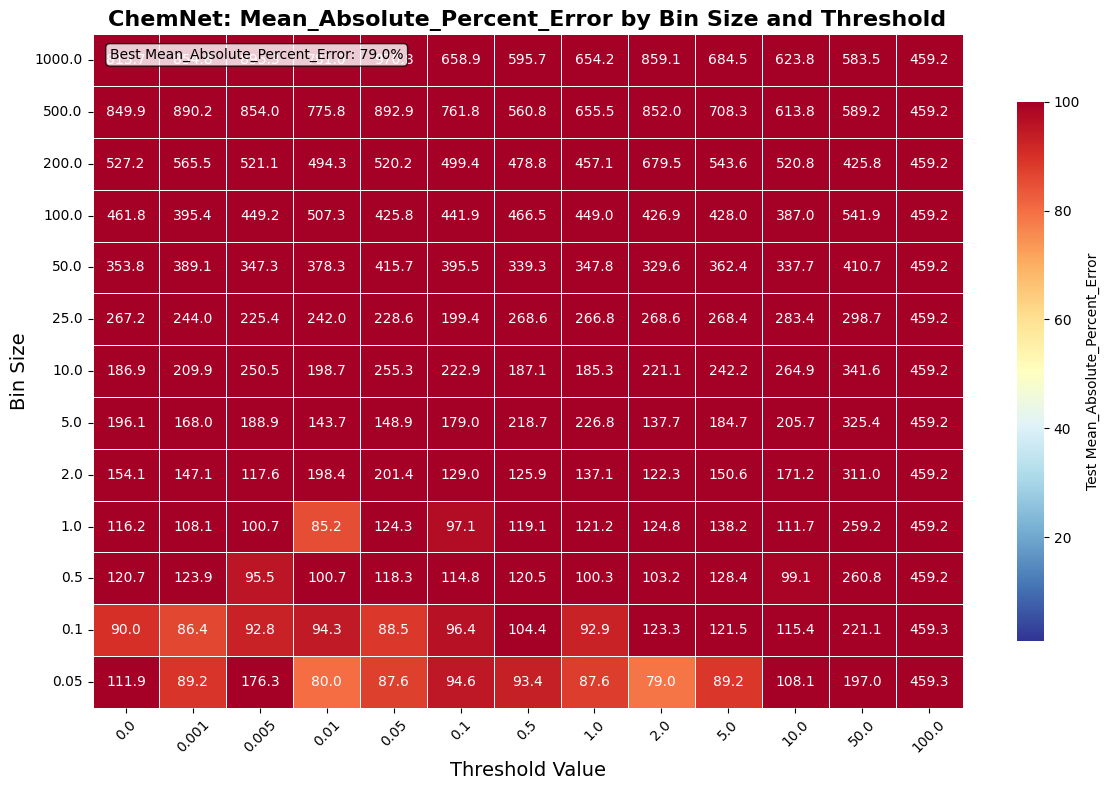

In [15]:
# Create the actual heatmaps for ChemNet visualization
# First, let's extract bin size and threshold from the ChemNet dataset names and add to results
def parse_chemnet_dataset_name(dataset_name):
    """Extract bin size and threshold from ChemNet dataset name"""
    # Remove 'chemnet_emb_' prefix
    name_part = dataset_name.replace('chemnet_emb_', '')
    
    # Handle thresh_zero case (no threshold)
    if 'thresh_zero' in name_part:
        # Extract bin size
        bin_part = name_part.split('_thresh_zero')[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        threshold = 0.0
    else:
        # Extract bin size and threshold
        parts = name_part.split('_thresh')
        bin_part = parts[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        
        thresh_part = parts[1].split('_df_spectra')[0]
        threshold = float(thresh_part.replace('_', '.'))
    
    return bin_size, threshold

# Add bin_size and threshold columns to ChemNet results DataFrames
for df_results in [df_chemnet_r2_results, df_chemnet_percent_error_results]:
    bin_sizes = []
    thresholds = []
    
    for dataset_name in df_results['Dataset']:
        bin_size, threshold = parse_chemnet_dataset_name(dataset_name)
        bin_sizes.append(bin_size)
        thresholds.append(threshold)
    
    df_results['BinSize'] = bin_sizes
    df_results['Threshold'] = thresholds

# Check for and remove duplicates before creating pivot tables
print("Checking for duplicates in ChemNet results...")
print(f"Original df_chemnet_r2_results shape: {df_chemnet_r2_results.shape}")

# Remove duplicates based on BinSize + Threshold combination (keep first occurrence)
df_chemnet_r2_results = df_chemnet_r2_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')
df_chemnet_percent_error_results = df_chemnet_percent_error_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')

print(f"After removing duplicates: {df_chemnet_r2_results.shape}")

# Now create pivot tables for ChemNet
chemnet_r2_pivot = df_chemnet_r2_results.pivot(index='BinSize', columns='Threshold', values='Test_R2') 
chemnet_median_percent_error_pivot = df_chemnet_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Test_Median_Percent_Error')
chemnet_mean_percent_error_pivot = df_chemnet_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Test_Mean_Percent_Error')

# List all expected thresholds
thresholds_subset = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
bins_subset = [0.05, 0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]

# Reindex pivot tables to show all columns, filling missing with NaN
chemnet_r2_pivot = chemnet_r2_pivot.reindex(columns=thresholds_subset, index=bins_subset)
chemnet_median_percent_error_pivot = chemnet_median_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)
chemnet_mean_percent_error_pivot = chemnet_mean_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)


# Also create individual larger heatmaps for ChemNet for better detail
def create_detailed_heatmap_chemnet(pivot_data, metric_name, cmap, figsize=(12, 8), vmin=None, vmax=None):
    """Create a detailed heatmap for a single ChemNet metric"""
    plt.figure(figsize=figsize)
    
    # Create heatmap
    sns.heatmap(pivot_data, 
                annot=True, 
                fmt='.3f' if 'R²' in metric_name else '.1f', 
                cmap=cmap,
                square=False,
                linewidths=0.5,
                vmin=vmin,
                vmax=vmax,
                cbar_kws={'label': f'Test {metric_name}', 'shrink': 0.8})
    
    plt.title(f'ChemNet: {metric_name} by Bin Size and Threshold', fontsize=16, fontweight='bold')
    plt.xlabel('Threshold Value', fontsize=14)
    plt.ylabel('Bin Size', fontsize=14)
    plt.gca().invert_yaxis()
    
    # Improve readability
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # Add text annotation for best performance
    if 'R²' in metric_name:
        best_val = pivot_data.max().max()
        plt.text(0.02, 0.98, f'Best R²: {best_val:.4f}', 
                transform=plt.gca().transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                verticalalignment='top')
    else:
        best_val = pivot_data.min().min()
        plt.text(0.02, 0.98, f'Best {metric_name}: {best_val:.1f}%', 
                transform=plt.gca().transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                verticalalignment='top')
    
    plt.tight_layout()
    plt.savefig(f"/home/dlipsey/MITLincolnLabs/Figures/ChemNet_{metric_name}_by_Bin_Size_and_Threshold")

    plt.show()

# Create detailed individual ChemNet heatmaps
print("Creating detailed ChemNet heatmaps...")

# create_detailed_heatmap_chemnet(chemnet_r2_pivot, 'R²', 'RdYlBu')     
create_detailed_heatmap_chemnet(chemnet_median_percent_error_pivot, 'Median_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0) 
create_detailed_heatmap_chemnet(chemnet_mean_percent_error_pivot, 'Mean_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0)

# Conditional Encoder Heatmap

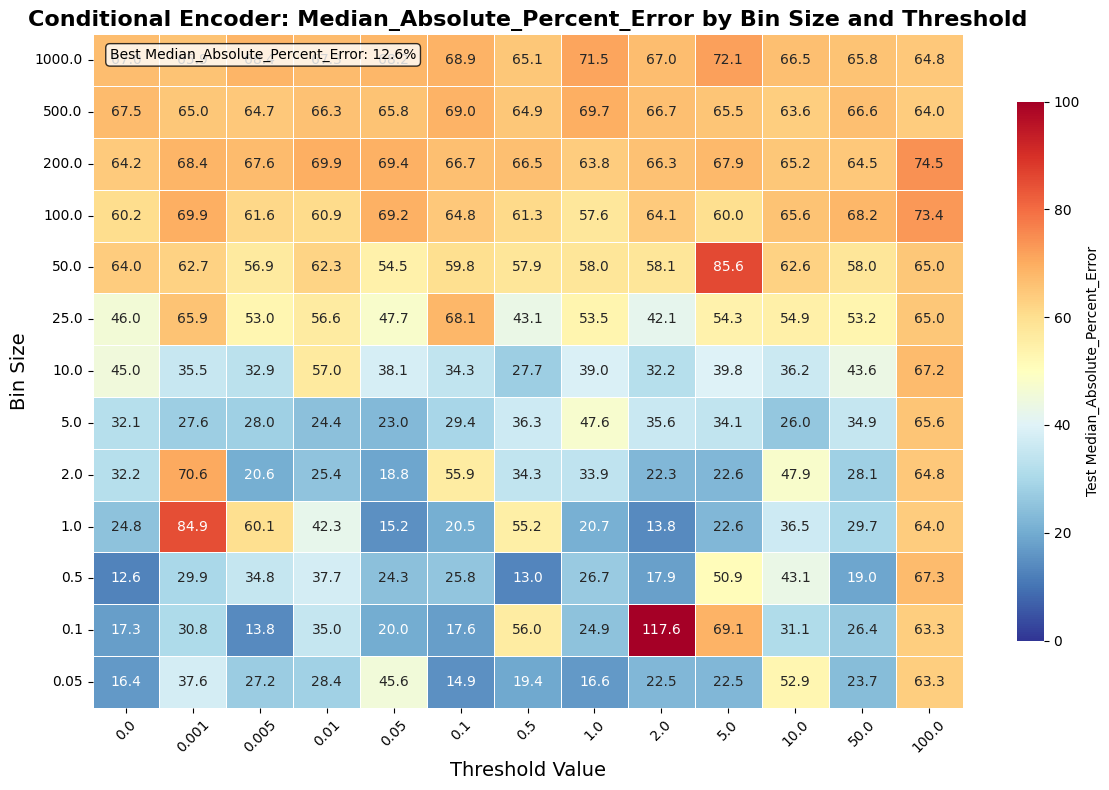

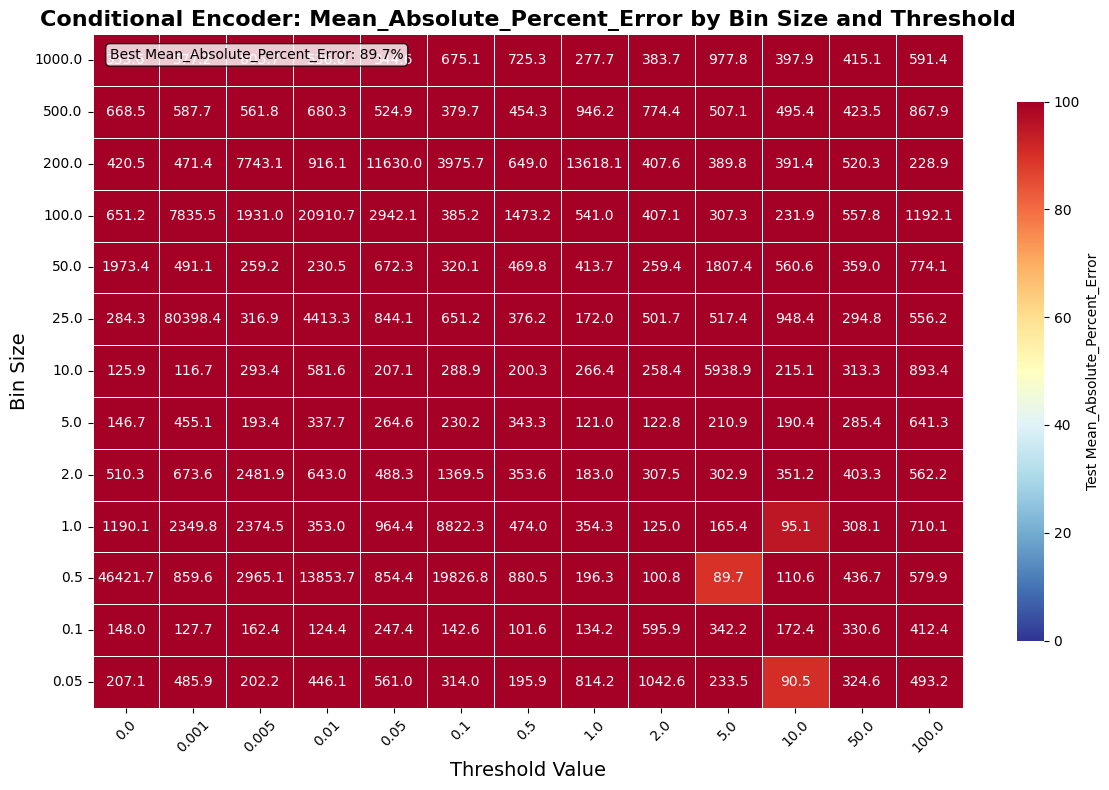

In [18]:
# This uses the saved Conditional Encoder Output dataframes, whichever training method is their source to make grid search heatmaps
# and then to make the outlier histograms that we also want.


cond_enc_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_outputs"
cond_enc_files = [f for f in os.listdir(cond_enc_folder) if f.endswith('.pkl') and f.startswith('cond_enc_')]

# Storage for conditional encoder results
cond_encoder_results = []

for i, file_name in enumerate(sorted(cond_enc_files), 1):
    try:
        # Load conditional encoder outputs
        file_path = os.path.join(cond_enc_folder, file_name)
        cond_df = pd.read_pickle(file_path)
        
        # Extract dataset name (remove 'cond_enc_' prefix and '.pkl' suffix)
        dataset_name = file_name.replace('cond_enc_', '').replace('.pkl', '')
        
        # Check if required columns exist
        if 'cond_tox_pred' not in cond_df.columns or 'log_response' not in cond_df.columns:
            continue
        
        # Split data into train/test (same logic as your conditional encoder training)
        # Use SMILES grouping to ensure proper split
        counts = cond_df['SMILES_spectra'].value_counts()
        valid_smiles = counts[counts >= 4].index
        filtered_df = cond_df[cond_df['SMILES_spectra'].isin(valid_smiles)].copy()
        
        if len(filtered_df) < 20:
            continue
        
        # Create train/test split by SMILES
        train_indices = []
        test_indices = []
        
        np.random.seed(42)
        for smiles, group in filtered_df.groupby('SMILES_spectra'):
            idx = group.index.tolist()
            n = len(idx)
            np.random.shuffle(idx)
            split = n // 2
            test_idx = idx[:split]
            train_idx = idx[split:]
            train_indices.extend(train_idx)
            test_indices.extend(test_idx)
        
        train_data = filtered_df.loc[train_indices]
        test_data = filtered_df.loc[test_indices]
        
        # Get predictions and true values
        train_pred = train_data['cond_tox_pred'].values
        train_true = train_data['log_response'].values
        test_pred = test_data['cond_tox_pred'].values
        test_true = test_data['log_response'].values
        
        # Calculate percent errors (undo log transform to get back to original response scale)
        train_response_true = np.exp(train_true)
        train_response_pred = np.exp(train_pred)
        test_response_true = np.exp(test_true)
        test_response_pred = np.exp(test_pred)
        
        # Calculate absolute percent errors
        train_median_percent_error = 100 * np.median(np.abs(train_response_pred - train_response_true) / train_response_true)
        test_median_percent_error = 100 * np.median(np.abs(test_response_pred - test_response_true) / test_response_true)
        train_mean_percent_error = 100 * np.mean(np.abs(train_response_pred - train_response_true) / train_response_true)
        test_mean_percent_error = 100 * np.mean(np.abs(test_response_pred - test_response_true) / test_response_true)
        
        # Store results
        cond_encoder_results.append({
            'Dataset': dataset_name,
            'Train_Median_Percent_Error': train_median_percent_error,
            'Test_Median_Percent_Error': test_median_percent_error,
            'Train_Mean_Percent_Error': train_mean_percent_error,
            'Test_Mean_Percent_Error': test_mean_percent_error,
            'Samples': len(filtered_df),
            'Train_Samples': len(train_data),
            'Test_Samples': len(test_data)
        })
        
    except Exception as e:
        continue

# Convert to DataFrame
df_cond_percent_error_results = pd.DataFrame(cond_encoder_results)

# Parse dataset names to extract bin sizes and thresholds
def parse_cond_dataset_name(dataset_name):
    """Extract bin size and threshold from dataset name"""
    if 'thresh_zero' in dataset_name:
        bin_part = dataset_name.split('_thresh_zero')[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        threshold = 0.0
    else:
        parts = dataset_name.split('_thresh')
        bin_part = parts[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        
        thresh_part = parts[1].split('_df_spectra')[0]
        threshold = float(thresh_part.replace('_', '.'))
    
    return bin_size, threshold

# Add bin size and threshold columns
bin_sizes = []
thresholds = []

for dataset_name in df_cond_percent_error_results['Dataset']:
    bin_size, threshold = parse_cond_dataset_name(dataset_name)
    bin_sizes.append(bin_size)
    thresholds.append(threshold)

df_cond_percent_error_results['BinSize'] = bin_sizes
df_cond_percent_error_results['Threshold'] = thresholds

# Create pivot tables for heatmaps
thresholds_subset = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
bins_subset = [0.05, 0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]

cond_median_error_pivot = df_cond_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Test_Median_Percent_Error')
cond_mean_error_pivot = df_cond_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Test_Mean_Percent_Error')

# Reindex to show all combinations
cond_median_error_pivot = cond_median_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)
cond_mean_error_pivot = cond_mean_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)

def create_detailed_heatmap_cond_enc(pivot_data, metric_name, cmap, figsize=(12, 8), vmin=None, vmax=None):
    """Create a detailed heatmap for a single conditional encoder metric"""
    plt.figure(figsize=figsize)
    
    # Create heatmap
    sns.heatmap(pivot_data, 
                annot=True, 
                fmt='.1f', 
                cmap=cmap,
                square=False,
                linewidths=0.5,
                vmin=vmin,
                vmax=vmax,
                cbar_kws={'label': f'Test {metric_name}', 'shrink': 0.8})
    
    plt.title(f'Conditional Encoder: {metric_name} by Bin Size and Threshold', fontsize=16, fontweight='bold')
    plt.xlabel('Threshold Value', fontsize=14)
    plt.ylabel('Bin Size', fontsize=14)
    plt.gca().invert_yaxis()
    
    # Improve readability
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # Add text annotation for best performance
    best_val = pivot_data.min().min()
    plt.text(0.02, 0.98, f'Best {metric_name}: {best_val:.1f}%', 
            transform=plt.gca().transAxes, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
            verticalalignment='top')
    
    plt.tight_layout()
    plt.savefig(f"/home/dlipsey/MITLincolnLabs/Figures/Conditional_encoder_{metric_name}_by_Bin_Size_and_Threshold")
    plt.show()

# Create detailed individual heatmaps
create_detailed_heatmap_cond_enc(cond_median_error_pivot, 'Median_Absolute_Percent_Error', 'RdYlBu_r', vmin=0, vmax=100) 
create_detailed_heatmap_cond_enc(cond_mean_error_pivot, 'Mean_Absolute_Percent_Error', 'RdYlBu_r', vmin=0, vmax=100)

best_median_error_idx = df_cond_percent_error_results['Test_Median_Percent_Error'].idxmin()
best_median_error_dataset = df_cond_percent_error_results.loc[best_median_error_idx, 'Dataset']
best_median_error_value = df_cond_percent_error_results.loc[best_median_error_idx, 'Test_Median_Percent_Error']

best_mean_error_idx = df_cond_percent_error_results['Test_Mean_Percent_Error'].idxmin()
best_mean_error_dataset = df_cond_percent_error_results.loc[best_mean_error_idx, 'Dataset']
best_mean_error_value = df_cond_percent_error_results.loc[best_mean_error_idx, 'Test_Mean_Percent_Error']

# Chronic Outlier Extraction

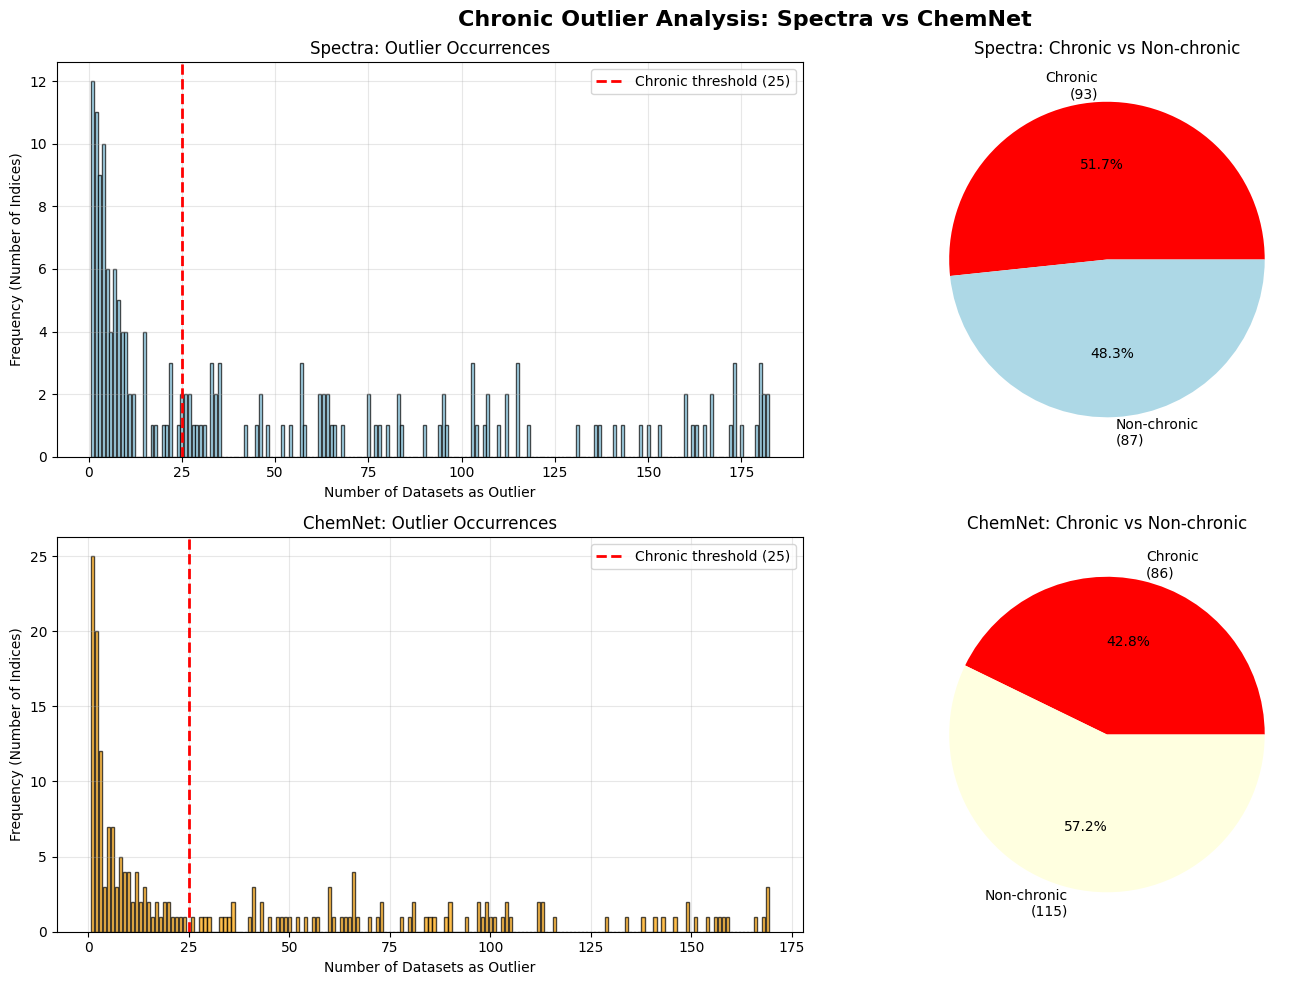


FINAL SUMMARY
Spectral chronic outliers: 93
ChemNet chronic outliers: 86
Overlap: 38

These index_ids represent spectra that are consistently difficult to predict
across multiple bin/threshold combinations within each method.


In [45]:
# Efficient chronic outlier identification
outlier_percentile = 95
chronic_threshold = 25

def process_outliers(saved_errors, folder_path, random_state, feature_filter=None):
    """Process outlier data efficiently for a given method"""
    chronic_outlier_counter = {}
    
    for dataset_name, individual_errors in saved_errors.items():
        if len(individual_errors) == 0:
            continue
            
        outlier_threshold = np.percentile(individual_errors, outlier_percentile)
        outlier_indices = np.where(individual_errors >= outlier_threshold)[0]
        
        try:
            file_path = os.path.join(folder_path, f"{dataset_name}.pkl")
            df = pd.read_pickle(file_path)
            
            # Filter features based on method
            if feature_filter:
                feature_cols = [col for col in df.columns if feature_filter(col)]
            else:
                feature_cols = [col for col in df.columns if col not in ['SMILES_spectra', 'Response', 'log_response', 'index_id']]
            
            X = df[feature_cols]
            y = df['log_response']
            
            valid_mask = ~(X.isna().any(axis=1) | y.isna())
            X_clean = X[valid_mask]
            y_clean = y[valid_mask]
            
            if len(X_clean) < 10:
                continue
                
            _, _, _, _, _, idx_test = train_test_split(
                X_clean, y_clean, df.loc[valid_mask, 'index_id'], 
                test_size=0.5, random_state=random_state
            )
            
            outlier_index_ids = idx_test.iloc[outlier_indices].tolist()
            
            for idx_id in outlier_index_ids:
                chronic_outlier_counter[idx_id] = chronic_outlier_counter.get(idx_id, 0) + 1
                
        except Exception:
            continue
    
    return chronic_outlier_counter

# Process spectra and chemnet outliers
spectra_chronic_outlier_counter = process_outliers(
    saved_spectral_errors, 
    "/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes", 
    42
)

chemnet_chronic_outlier_counter = process_outliers(
    saved_chemnet_errors, 
    "/home/dlipsey/MITLincolnLabs/MIT_LL_data/chemnet_grid_search_dataframes", 
    47,
    lambda col: col.startswith('emb_')
)

# Get chronic outlier IDs
chronic_spectra_outlier_ids = [idx for idx, count in spectra_chronic_outlier_counter.items() if count >= chronic_threshold]
chronic_chemnet_outlier_ids = [idx for idx, count in chemnet_chronic_outlier_counter.items() if count >= chronic_threshold]

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Chronic Outlier Analysis: Spectra vs ChemNet', fontsize=16, fontweight='bold')

# Plot 1: Distribution of outlier occurrences for Spectra
ax1 = axes[0, 0]
if len(spectra_chronic_outlier_counter) > 0:
    outlier_counts = list(spectra_chronic_outlier_counter.values())
    outlier_count_distribution = Counter(outlier_counts)
    counts = list(range(1, max(outlier_counts) + 1))
    frequencies = [outlier_count_distribution.get(c, 0) for c in counts]
    
    ax1.bar(counts, frequencies, alpha=0.7, color='skyblue', edgecolor='black')
    ax1.axvline(x=chronic_threshold, color='red', linestyle='--', linewidth=2, 
               label=f'Chronic threshold ({chronic_threshold})')
    ax1.set_xlabel('Number of Datasets as Outlier')
    ax1.set_ylabel('Frequency (Number of Indices)')
    ax1.set_title('Spectra: Outlier Occurrences')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

# Plot 2: Chronic vs non-chronic for Spectra
ax2 = axes[0, 1]
if len(spectra_chronic_outlier_counter) > 0:
    chronic_count = len(chronic_spectra_outlier_ids)
    non_chronic_count = len(spectra_chronic_outlier_counter) - chronic_count
    
    ax2.pie([chronic_count, non_chronic_count], 
            labels=[f'Chronic\n({chronic_count})', f'Non-chronic\n({non_chronic_count})'],
            autopct='%1.1f%%', colors=['red', 'lightblue'])
    ax2.set_title('Spectra: Chronic vs Non-chronic')

# Plot 3: Distribution of outlier occurrences for ChemNet
ax3 = axes[1, 0]
if len(chemnet_chronic_outlier_counter) > 0:
    outlier_counts = list(chemnet_chronic_outlier_counter.values())
    outlier_count_distribution = Counter(outlier_counts)
    counts = list(range(1, max(outlier_counts) + 1))
    frequencies = [outlier_count_distribution.get(c, 0) for c in counts]
    
    ax3.bar(counts, frequencies, alpha=0.7, color='orange', edgecolor='black')
    ax3.axvline(x=chronic_threshold, color='red', linestyle='--', linewidth=2, 
               label=f'Chronic threshold ({chronic_threshold})')
    ax3.set_xlabel('Number of Datasets as Outlier')
    ax3.set_ylabel('Frequency (Number of Indices)')
    ax3.set_title('ChemNet: Outlier Occurrences')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# Plot 4: Chronic vs non-chronic for ChemNet
ax4 = axes[1, 1]
if len(chemnet_chronic_outlier_counter) > 0:
    chronic_count = len(chronic_chemnet_outlier_ids)
    non_chronic_count = len(chemnet_chronic_outlier_counter) - chronic_count
    
    ax4.pie([chronic_count, non_chronic_count], 
            labels=[f'Chronic\n({chronic_count})', f'Non-chronic\n({non_chronic_count})'],
            autopct='%1.1f%%', colors=['red', 'lightyellow'])
    ax4.set_title('ChemNet: Chronic vs Non-chronic')

plt.tight_layout()
plt.savefig("/home/dlipsey/MITLincolnLabs/Figures/Chronic_Outlier_Analysis_Comparison")
plt.show()

print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")
print(f"Spectral chronic outliers: {len(chronic_spectra_outlier_ids)}")
print(f"ChemNet chronic outliers: {len(chronic_chemnet_outlier_ids)}")
print(f"Overlap: {len(set(chronic_spectra_outlier_ids) & set(chronic_chemnet_outlier_ids))}")
print("\nThese index_ids represent spectra that are consistently difficult to predict")
print("across multiple bin/threshold combinations within each method.")
print(f"{'='*60}")

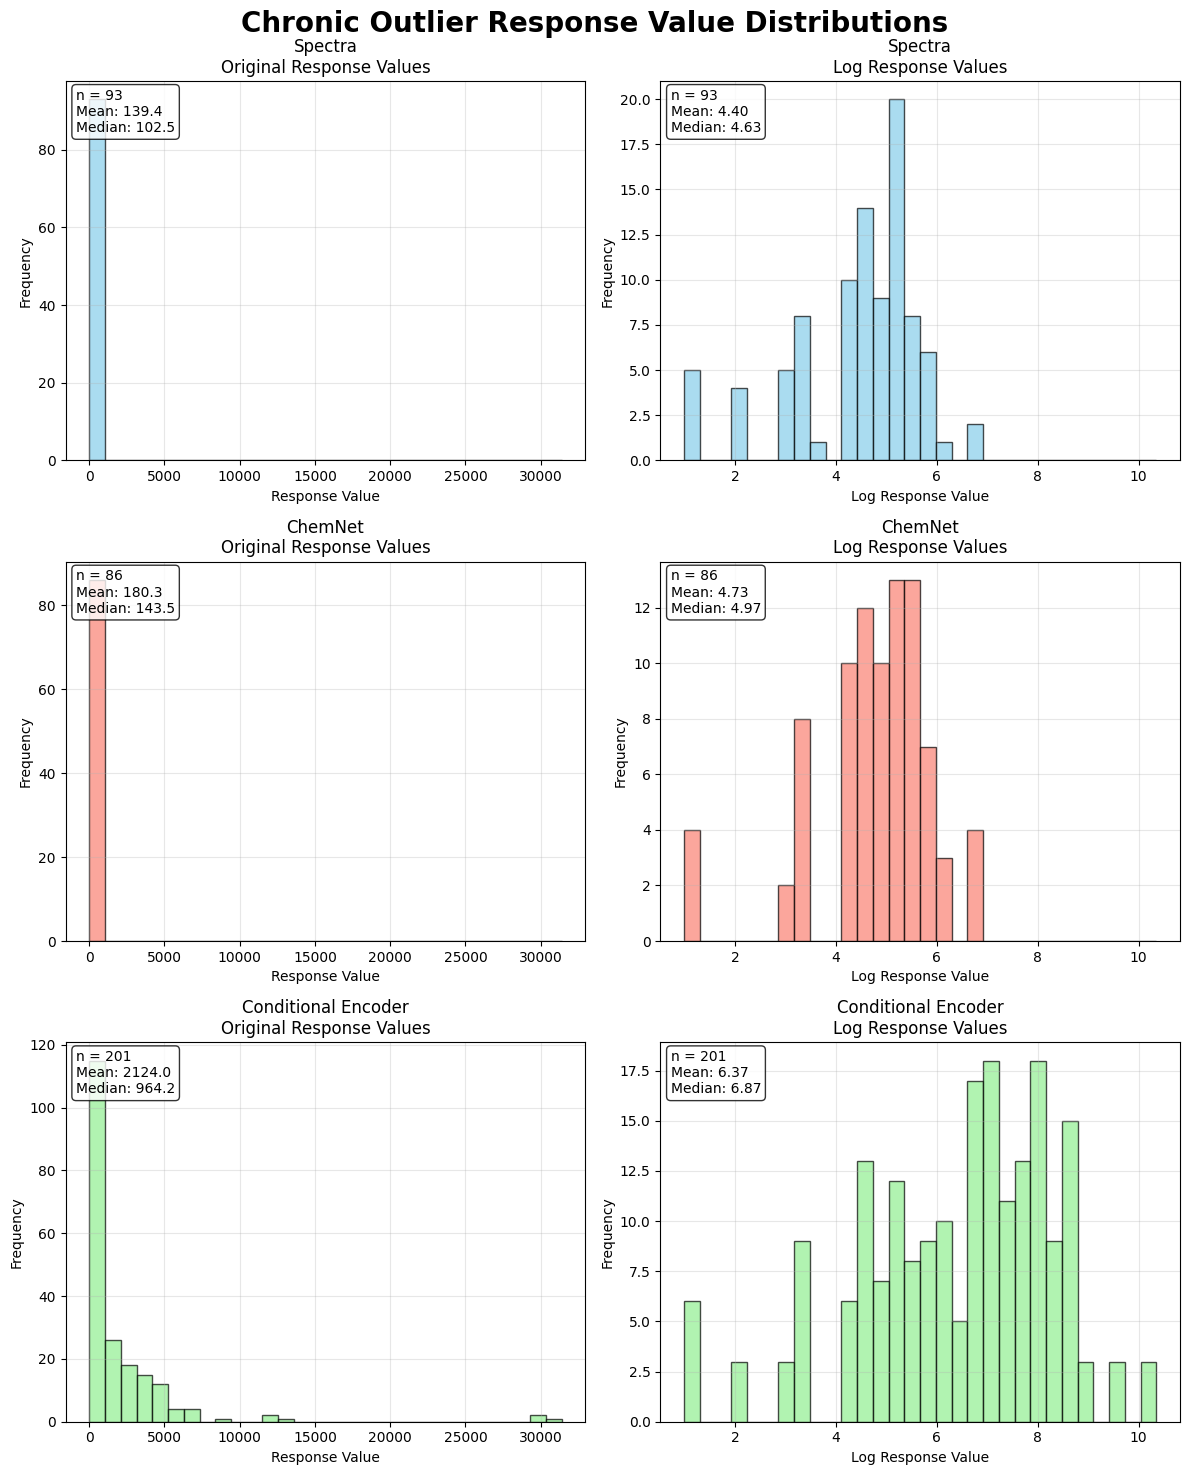

In [48]:
def get_chronic_outlier_responses(chronic_outlier_ids, method='spectral'):
    """Get true response values for chronic outliers"""
    response_values = []
    log_response_values = []
    
    if len(chronic_outlier_ids) == 0:
        return np.array(response_values), np.array(log_response_values)
    
    folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes" if method == 'spectral' else "/home/dlipsey/MITLincolnLabs/MIT_LL_data/chemnet_grid_search_dataframes"
    saved_errors = saved_spectral_errors if method == 'spectral' else saved_chemnet_errors
    
    # Use the first available dataset to get the mapping
    for dataset_name in saved_errors.keys():
        try:
            file_path = os.path.join(folder, f"{dataset_name}.pkl")
            if os.path.exists(file_path):
                df = pd.read_pickle(file_path)
                chronic_mask = df['index_id'].isin(chronic_outlier_ids)
                chronic_data = df[chronic_mask]
                
                if len(chronic_data) > 0:
                    response_values.extend(chronic_data['Response'].values)
                    log_response_values.extend(chronic_data['log_response'].values)
                    break
        except Exception:
            continue
    
    return np.array(response_values), np.array(log_response_values)

# Get chronic outlier response values for spectral and chemnet
spectral_responses, spectral_log_responses = get_chronic_outlier_responses(chronic_spectra_outlier_ids, 'spectral')
chemnet_responses, chemnet_log_responses = get_chronic_outlier_responses(chronic_chemnet_outlier_ids, 'chemnet')

# Identify conditional encoder chronic outliers - MODIFIED TO ONLY USE TEST SET
cond_enc_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_outputs"
cond_enc_chronic_outlier_counter = {}

for file_name in os.listdir(cond_enc_folder):
    if file_name.endswith('.pkl') and file_name.startswith('cond_enc_'):
        try:
            file_path = os.path.join(cond_enc_folder, file_name)
            cond_df = pd.read_pickle(file_path)
            
            if 'cond_tox_pred' in cond_df.columns and 'log_response' in cond_df.columns and 'index_id' in cond_df.columns:
                # Apply same train/test split logic as conditional encoder training
                counts = cond_df['SMILES_spectra'].value_counts()
                valid_smiles = counts[counts >= 4].index
                filtered_df = cond_df[cond_df['SMILES_spectra'].isin(valid_smiles)].copy()
                
                if len(filtered_df) < 20:
                    continue
                
                # Create train/test split by SMILES (same as conditional encoder training)
                train_indices = []
                test_indices = []
                
                np.random.seed(42)
                for smiles, group in filtered_df.groupby('SMILES_spectra'):
                    idx = group.index.tolist()
                    n = len(idx)
                    np.random.shuffle(idx)
                    split = n // 2
                    test_idx = idx[:split]
                    train_idx = idx[split:]
                    train_indices.extend(train_idx)
                    test_indices.extend(test_idx)
                
                # Only use TEST SET data for outlier identification
                test_data = filtered_df.loc[test_indices]
                
                if len(test_data) == 0:
                    continue
                
                y_true = test_data['log_response'].values
                y_pred = test_data['cond_tox_pred'].values
                
                individual_errors = np.abs((np.exp(y_pred) - np.exp(y_true)) / np.exp(y_true)) * 100
                outlier_threshold = np.percentile(individual_errors, 95)
                outlier_indices = np.where(individual_errors >= outlier_threshold)[0]
                
                # Get outlier index_ids from TEST SET only
                outlier_index_ids = test_data.iloc[outlier_indices]['index_id'].tolist()
                
                for idx_id in outlier_index_ids:
                    cond_enc_chronic_outlier_counter[idx_id] = cond_enc_chronic_outlier_counter.get(idx_id, 0) + 1
        except Exception:
            continue

# Get conditional encoder chronic outliers and their response values
chronic_cond_outlier_ids = [idx for idx, count in cond_enc_chronic_outlier_counter.items() if count >= chronic_threshold]
cond_enc_responses = []
cond_enc_log_responses = []

for file_name in os.listdir(cond_enc_folder):
    if file_name.endswith('.pkl') and file_name.startswith('cond_enc_'):
        try:
            file_path = os.path.join(cond_enc_folder, file_name)
            cond_df = pd.read_pickle(file_path)
            
            if 'index_id' in cond_df.columns:
                chronic_mask = cond_df['index_id'].isin(chronic_cond_outlier_ids)
                chronic_data = cond_df[chronic_mask]
                
                if len(chronic_data) > 0:
                    cond_enc_responses.extend(chronic_data['Response'].values)
                    cond_enc_log_responses.extend(chronic_data['log_response'].values)
                    break
        except Exception:
            continue

cond_enc_responses = np.array(cond_enc_responses)
cond_enc_log_responses = np.array(cond_enc_log_responses)

# Create histograms
methods = ['Spectra', 'ChemNet', 'Conditional Encoder']
response_data = [spectral_responses, chemnet_responses, cond_enc_responses]
log_response_data = [spectral_log_responses, chemnet_log_responses, cond_enc_log_responses]

# Calculate uniform bin edges
all_responses = [val for responses in response_data if len(responses) > 0 for val in responses]
all_log_responses = [val for log_responses in log_response_data if len(log_responses) > 0 for val in log_responses]

n_bins = 30
response_bins = np.linspace(min(all_responses), max(all_responses), n_bins + 1) if all_responses else None
log_response_bins = np.linspace(min(all_log_responses), max(all_log_responses), n_bins + 1) if all_log_responses else None

# Create the 3x2 plot
fig, axes = plt.subplots(3, 2, figsize=(12, 15))
fig.suptitle('Chronic Outlier Response Value Distributions', fontsize=20, fontweight='bold')
colors = ['skyblue', 'salmon', 'lightgreen']
plot_titles = ['Original Response Values', 'Log Response Values']

for method_idx, (method_name, responses, log_responses, color) in enumerate(zip(methods, response_data, log_response_data, colors)):
    if len(responses) == 0:
        for plot_idx in range(2):
            ax = axes[method_idx, plot_idx]
            ax.text(0.5, 0.5, f'No chronic outliers\nfound for {method_name}', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=12)
            ax.set_title(f'{method_name}\n{plot_titles[plot_idx]}')
        continue
    
    # Original response values
    ax1 = axes[method_idx, 0]
    bins = response_bins if response_bins is not None else n_bins
    ax1.hist(responses, bins=bins, alpha=0.7, color=color, edgecolor='black')
    ax1.set_xlabel('Response Value')
    ax1.set_ylabel('Frequency')
    ax1.set_title(f'{method_name}\n{plot_titles[0]}')
    ax1.grid(True, alpha=0.3)
    ax1.text(0.02, 0.98, f'n = {len(responses)}\nMean: {np.mean(responses):.1f}\nMedian: {np.median(responses):.1f}', 
            transform=ax1.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Log response values
    ax2 = axes[method_idx, 1]
    bins = log_response_bins if log_response_bins is not None else n_bins
    ax2.hist(log_responses, bins=bins, alpha=0.7, color=color, edgecolor='black')
    ax2.set_xlabel('Log Response Value')
    ax2.set_ylabel('Frequency')
    ax2.set_title(f'{method_name}\n{plot_titles[1]}')
    ax2.grid(True, alpha=0.3)
    ax2.text(0.02, 0.98, f'n = {len(log_responses)}\nMean: {np.mean(log_responses):.2f}\nMedian: {np.median(log_responses):.2f}', 
            transform=ax2.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig("/home/dlipsey/MITLincolnLabs/Figures/Chronic_Outlier_Response_Distributions")
plt.show()

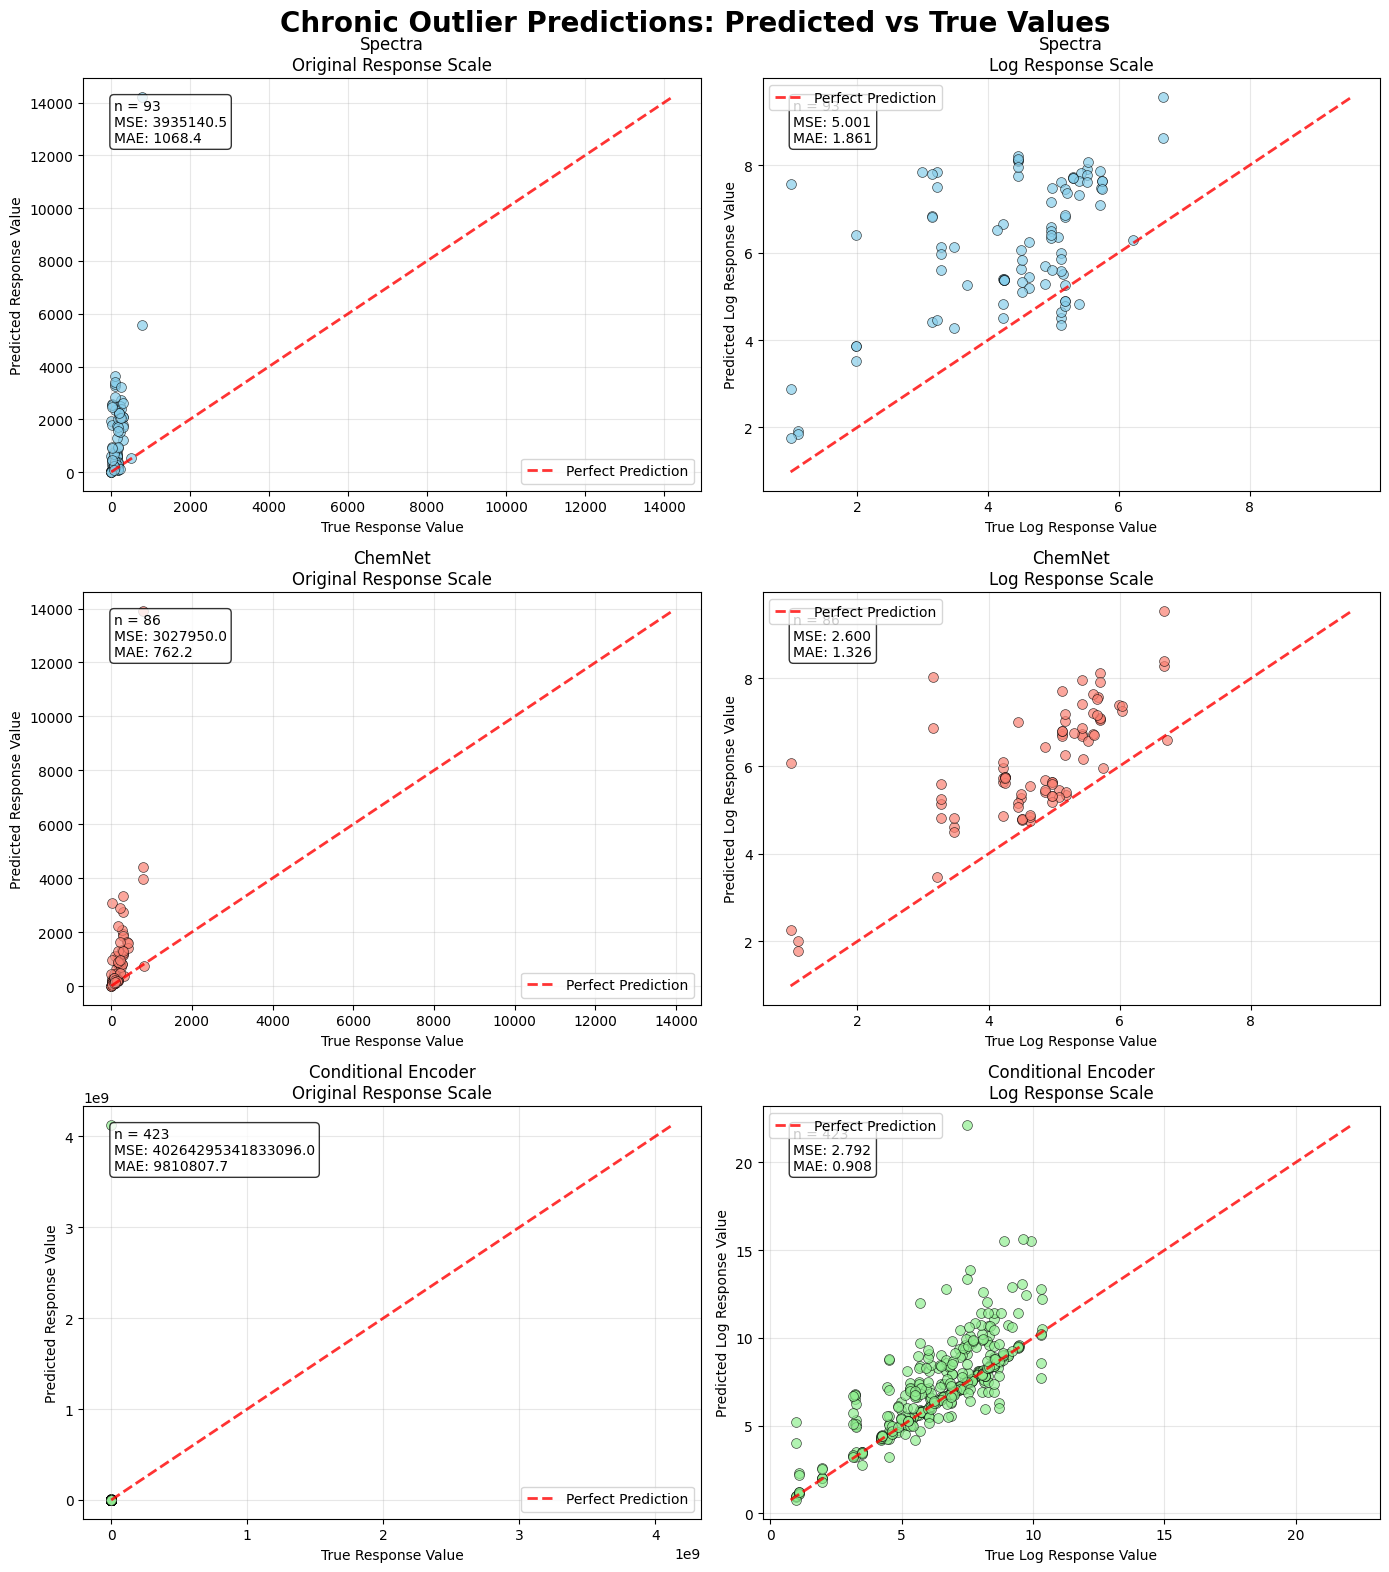

In [47]:
def get_chronic_outlier_predictions(chronic_outlier_ids, saved_errors, folder_path, random_state, feature_filter=None):
    """Get predicted and true values for chronic outliers from the best performing dataset"""
    if len(chronic_outlier_ids) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])
    
    best_dataset = None
    best_error = float('inf')
    
    # Find the dataset with lowest median error
    for dataset_name, individual_errors in saved_errors.items():
        if len(individual_errors) > 0:
            median_error = np.median(individual_errors)
            if median_error < best_error:
                best_error = median_error
                best_dataset = dataset_name
    
    if best_dataset is None:
        return np.array([]), np.array([]), np.array([]), np.array([])
    
    try:
        file_path = os.path.join(folder_path, f"{best_dataset}.pkl")
        df = pd.read_pickle(file_path)
        
        # Filter features based on method
        if feature_filter:
            feature_cols = [col for col in df.columns if feature_filter(col)]
        else:
            feature_cols = [col for col in df.columns if col not in ['SMILES_spectra', 'Response', 'log_response', 'index_id']]
        
        X = df[feature_cols]
        y = df['log_response']
        
        valid_mask = ~(X.isna().any(axis=1) | y.isna())
        X_clean = X[valid_mask]
        y_clean = y[valid_mask]
        
        if len(X_clean) < 10:
            return np.array([]), np.array([]), np.array([]), np.array([])
        
        # Split and train model (same as original)
        X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
            X_clean, y_clean, df.loc[valid_mask, 'index_id'], 
            test_size=0.5, random_state=random_state
        )
        
        rf = RandomForestRegressor(n_estimators=100, random_state=random_state, n_jobs=2)
        rf.fit(X_train, y_train)
        y_test_pred = rf.predict(X_test)
        
        # Filter for chronic outliers only
        chronic_mask = idx_test.isin(chronic_outlier_ids)
        chronic_indices = idx_test[chronic_mask].index
        
        if len(chronic_indices) == 0:
            return np.array([]), np.array([]), np.array([]), np.array([])
        
        # Get test set positions for chronic outliers
        test_positions = [list(idx_test.index).index(idx) for idx in chronic_indices]
        
        chronic_true_log = y_test.iloc[test_positions].values
        chronic_pred_log = y_test_pred[test_positions]
        chronic_true_response = np.exp(chronic_true_log)
        chronic_pred_response = np.exp(chronic_pred_log)
        
        return chronic_true_response, chronic_pred_response, chronic_true_log, chronic_pred_log
        
    except Exception as e:
        return np.array([]), np.array([]), np.array([]), np.array([])

def get_cond_enc_chronic_predictions(chronic_outlier_ids):
    """Get predicted and true values for conditional encoder chronic outliers"""
    if len(chronic_outlier_ids) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])
    
    cond_enc_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_outputs"
    best_error = float('inf')
    best_data = None
    
    # Find best performing conditional encoder dataset
    for file_name in os.listdir(cond_enc_folder):
        if file_name.endswith('.pkl') and file_name.startswith('cond_enc_'):
            try:
                file_path = os.path.join(cond_enc_folder, file_name)
                cond_df = pd.read_pickle(file_path)
                
                if 'cond_tox_pred' in cond_df.columns and 'log_response' in cond_df.columns:
                    y_true = cond_df['log_response'].values
                    y_pred = cond_df['cond_tox_pred'].values
                    
                    individual_errors = np.abs((np.exp(y_pred) - np.exp(y_true)) / np.exp(y_true)) * 100
                    median_error = np.median(individual_errors)
                    
                    if median_error < best_error:
                        best_error = median_error
                        best_data = cond_df.copy()
            except Exception:
                continue
    
    if best_data is None:
        return np.array([]), np.array([]), np.array([]), np.array([])
    
    # Filter for chronic outliers
    if 'index_id' in best_data.columns:
        chronic_mask = best_data['index_id'].isin(chronic_outlier_ids)
        chronic_data = best_data[chronic_mask]
        
        if len(chronic_data) > 0:
            chronic_true_log = chronic_data['log_response'].values
            chronic_pred_log = chronic_data['cond_tox_pred'].values
            chronic_true_response = np.exp(chronic_true_log)
            chronic_pred_response = np.exp(chronic_pred_log)
            
            return chronic_true_response, chronic_pred_response, chronic_true_log, chronic_pred_log
    
    return np.array([]), np.array([]), np.array([]), np.array([])

# Get predictions for chronic outliers from each method
spectra_true_resp, spectra_pred_resp, spectra_true_log, spectra_pred_log = get_chronic_outlier_predictions(
    chronic_spectra_outlier_ids, saved_spectral_errors, 
    "/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes", 42
)

chemnet_true_resp, chemnet_pred_resp, chemnet_true_log, chemnet_pred_log = get_chronic_outlier_predictions(
    chronic_chemnet_outlier_ids, saved_chemnet_errors, 
    "/home/dlipsey/MITLincolnLabs/MIT_LL_data/chemnet_grid_search_dataframes", 47,
    lambda col: col.startswith('emb_')
)

cond_enc_true_resp, cond_enc_pred_resp, cond_enc_true_log, cond_enc_pred_log = get_cond_enc_chronic_predictions(
    chronic_cond_outlier_ids
)

# Create the prediction scatter plots
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle('Chronic Outlier Predictions: Predicted vs True Values', fontsize=20, fontweight='bold')

methods = ['Spectra', 'ChemNet', 'Conditional Encoder']
pred_data = [
    (spectra_true_resp, spectra_pred_resp, spectra_true_log, spectra_pred_log),
    (chemnet_true_resp, chemnet_pred_resp, chemnet_true_log, chemnet_pred_log),
    (cond_enc_true_resp, cond_enc_pred_resp, cond_enc_true_log, cond_enc_pred_log)
]
colors = ['skyblue', 'salmon', 'lightgreen']
plot_titles = ['Original Response Scale', 'Log Response Scale']

for method_idx, (method_name, (true_resp, pred_resp, true_log, pred_log), color) in enumerate(zip(methods, pred_data, colors)):
    if len(true_resp) == 0:
        for plot_idx in range(2):
            ax = axes[method_idx, plot_idx]
            ax.text(0.5, 0.5, f'No chronic outlier\npredictions available\nfor {method_name}', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=12)
            ax.set_title(f'{method_name}\n{plot_titles[plot_idx]}')
        continue
    
    # Plot 1: Original response scale
    ax1 = axes[method_idx, 0]
    ax1.scatter(true_resp, pred_resp, alpha=0.7, color=color, s=50, edgecolor='black', linewidth=0.5)
    
    # Add perfect prediction line (y = x)
    min_val = min(min(true_resp), min(pred_resp))
    max_val = max(max(true_resp), max(pred_resp))
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, alpha=0.8, label='Perfect Prediction')
    
    ax1.set_xlabel('True Response Value')
    ax1.set_ylabel('Predicted Response Value')
    ax1.set_title(f'{method_name}\n{plot_titles[0]}')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Add statistics
    mse = np.mean((pred_resp - true_resp)**2)
    mae = np.mean(np.abs(pred_resp - true_resp))
    ax1.text(0.05, 0.95, f'n = {len(true_resp)}\nMSE: {mse:.1f}\nMAE: {mae:.1f}', 
            transform=ax1.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Plot 2: Log response scale
    ax2 = axes[method_idx, 1]
    ax2.scatter(true_log, pred_log, alpha=0.7, color=color, s=50, edgecolor='black', linewidth=0.5)
    
    # Add perfect prediction line (y = x)
    min_val = min(min(true_log), min(pred_log))
    max_val = max(max(true_log), max(pred_log))
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, alpha=0.8, label='Perfect Prediction')
    
    ax2.set_xlabel('True Log Response Value')
    ax2.set_ylabel('Predicted Log Response Value')
    ax2.set_title(f'{method_name}\n{plot_titles[1]}')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # Add statistics
    mse_log = np.mean((pred_log - true_log)**2)
    mae_log = np.mean(np.abs(pred_log - true_log))
    ax2.text(0.05, 0.95, f'n = {len(true_log)}\nMSE: {mse_log:.3f}\nMAE: {mae_log:.3f}', 
            transform=ax2.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig("/home/dlipsey/MITLincolnLabs/Figures/Chronic_Outlier_Predictions_vs_True")
plt.show()

# Constant Bin/Threshold Line Plots

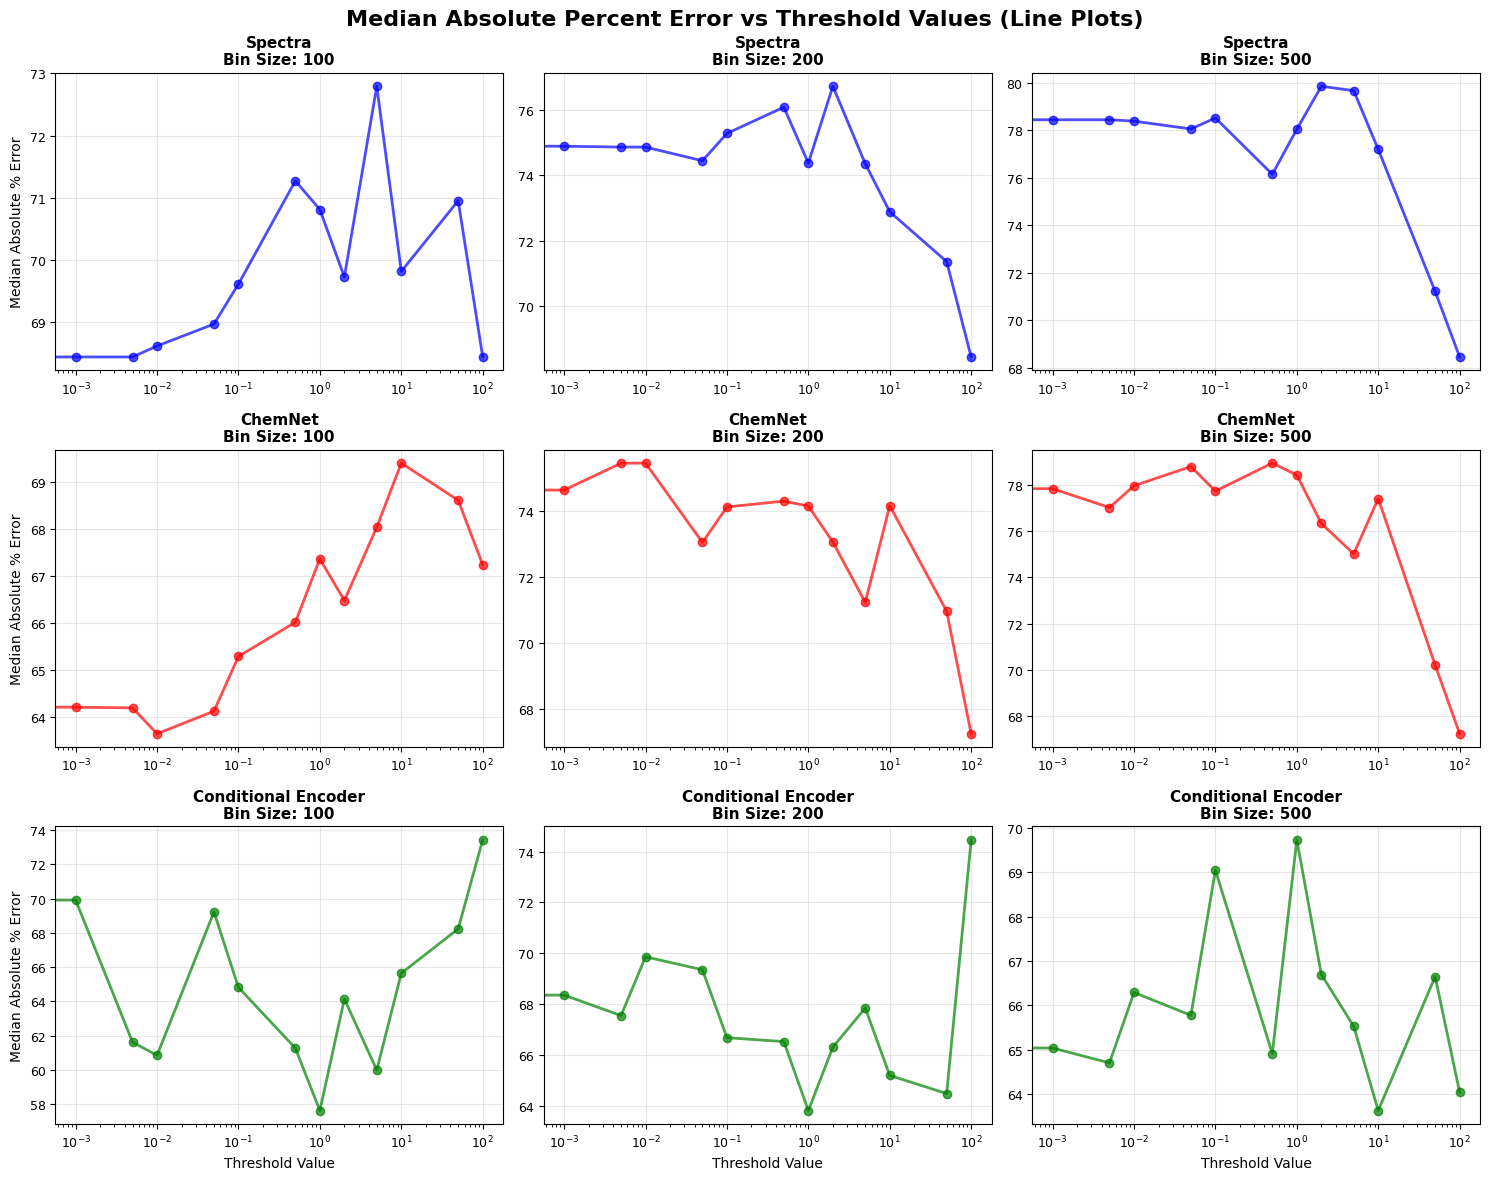

=== LINE PLOTS SUMMARY ===

Spectra:
  Bin 100: 13 data points, min error: 68.4%
  Bin 200: 13 data points, min error: 68.4%
  Bin 500: 13 data points, min error: 68.4%

ChemNet:
  Bin 100: 13 data points, min error: 63.6%
  Bin 200: 13 data points, min error: 67.2%
  Bin 500: 13 data points, min error: 67.2%

Conditional Encoder:
  Bin 100: 13 data points, min error: 57.6%
  Bin 200: 13 data points, min error: 63.8%
  Bin 500: 13 data points, min error: 63.6%


In [22]:
# Configuration - easily changeable bin sizes
selected_bin_sizes = [100, 200, 500]  # Change these values as needed

# Extract data for the selected bin sizes
def extract_data_for_bin_sizes(results_df, bin_sizes):
    """Extract median percent error data for selected bin sizes"""
    data = {}
    for bin_size in bin_sizes:
        bin_data = results_df[results_df['BinSize'] == bin_size].copy()
        if not bin_data.empty:
            # Sort by threshold for proper line plotting
            bin_data = bin_data.sort_values('Threshold')
            data[bin_size] = {
                'thresholds': bin_data['Threshold'].values,
                'median_errors': bin_data['Test_Median_Percent_Error'].values
            }
    return data

# Extract data for all three methods
spectra_data = extract_data_for_bin_sizes(df_percent_error_results, selected_bin_sizes)
chemnet_data = extract_data_for_bin_sizes(df_chemnet_percent_error_results, selected_bin_sizes)
cond_enc_data = extract_data_for_bin_sizes(df_cond_percent_error_results, selected_bin_sizes)

# Create 3x3 grid of line plots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Median Absolute Percent Error vs Threshold Values (Line Plots)', fontsize=16, fontweight='bold')

methods = ['Spectra', 'ChemNet', 'Conditional Encoder']
data_sources = [spectra_data, chemnet_data, cond_enc_data]
colors = ['blue', 'red', 'green']

for method_idx, (method_name, method_data, color) in enumerate(zip(methods, data_sources, colors)):
    for bin_idx, bin_size in enumerate(selected_bin_sizes):
        ax = axes[method_idx, bin_idx]
        
        if bin_size in method_data:
            thresholds = method_data[bin_size]['thresholds']
            errors = method_data[bin_size]['median_errors']
            
            # Plot line with markers
            ax.plot(thresholds, errors, marker='o', linewidth=2, markersize=6, 
                   color=color, alpha=0.7, label=f'Bin {bin_size}')
            
            # Add grid
            ax.grid(True, alpha=0.3)
            
            # Set labels
            if method_idx == 2:  # Bottom row
                ax.set_xlabel('Threshold Value', fontsize=10)
            if bin_idx == 0:  # Left column
                ax.set_ylabel('Median Absolute % Error', fontsize=10)
            
            # Set title
            ax.set_title(f'{method_name}\nBin Size: {bin_size}', fontsize=11, fontweight='bold')
            
            # Set x-axis to log scale if needed (thresholds span many orders of magnitude)
            if len(thresholds) > 1 and max(thresholds) / min(thresholds[thresholds > 0]) > 100:
                ax.set_xscale('log')
            
            # Add some styling
            ax.tick_params(axis='both', which='major', labelsize=9)
            
        else:
            # No data available
            ax.text(0.5, 0.5, f'No data for\n{method_name}\nBin {bin_size}', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=10)
            ax.set_title(f'{method_name}\nBin Size: {bin_size}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("/home/dlipsey/MITLincolnLabs/Figures/Median_Error_vs_Threshold_Line_Plots_large_bins")
plt.show()

# Print summary of what was plotted
print("=== LINE PLOTS SUMMARY ===")
for method_name, method_data in zip(methods, data_sources):
    print(f"\n{method_name}:")
    for bin_size in selected_bin_sizes:
        if bin_size in method_data:
            n_points = len(method_data[bin_size]['thresholds'])
            min_error = min(method_data[bin_size]['median_errors'])
            print(f"  Bin {bin_size}: {n_points} data points, min error: {min_error:.1f}%")
        else:
            print(f"  Bin {bin_size}: No data available")

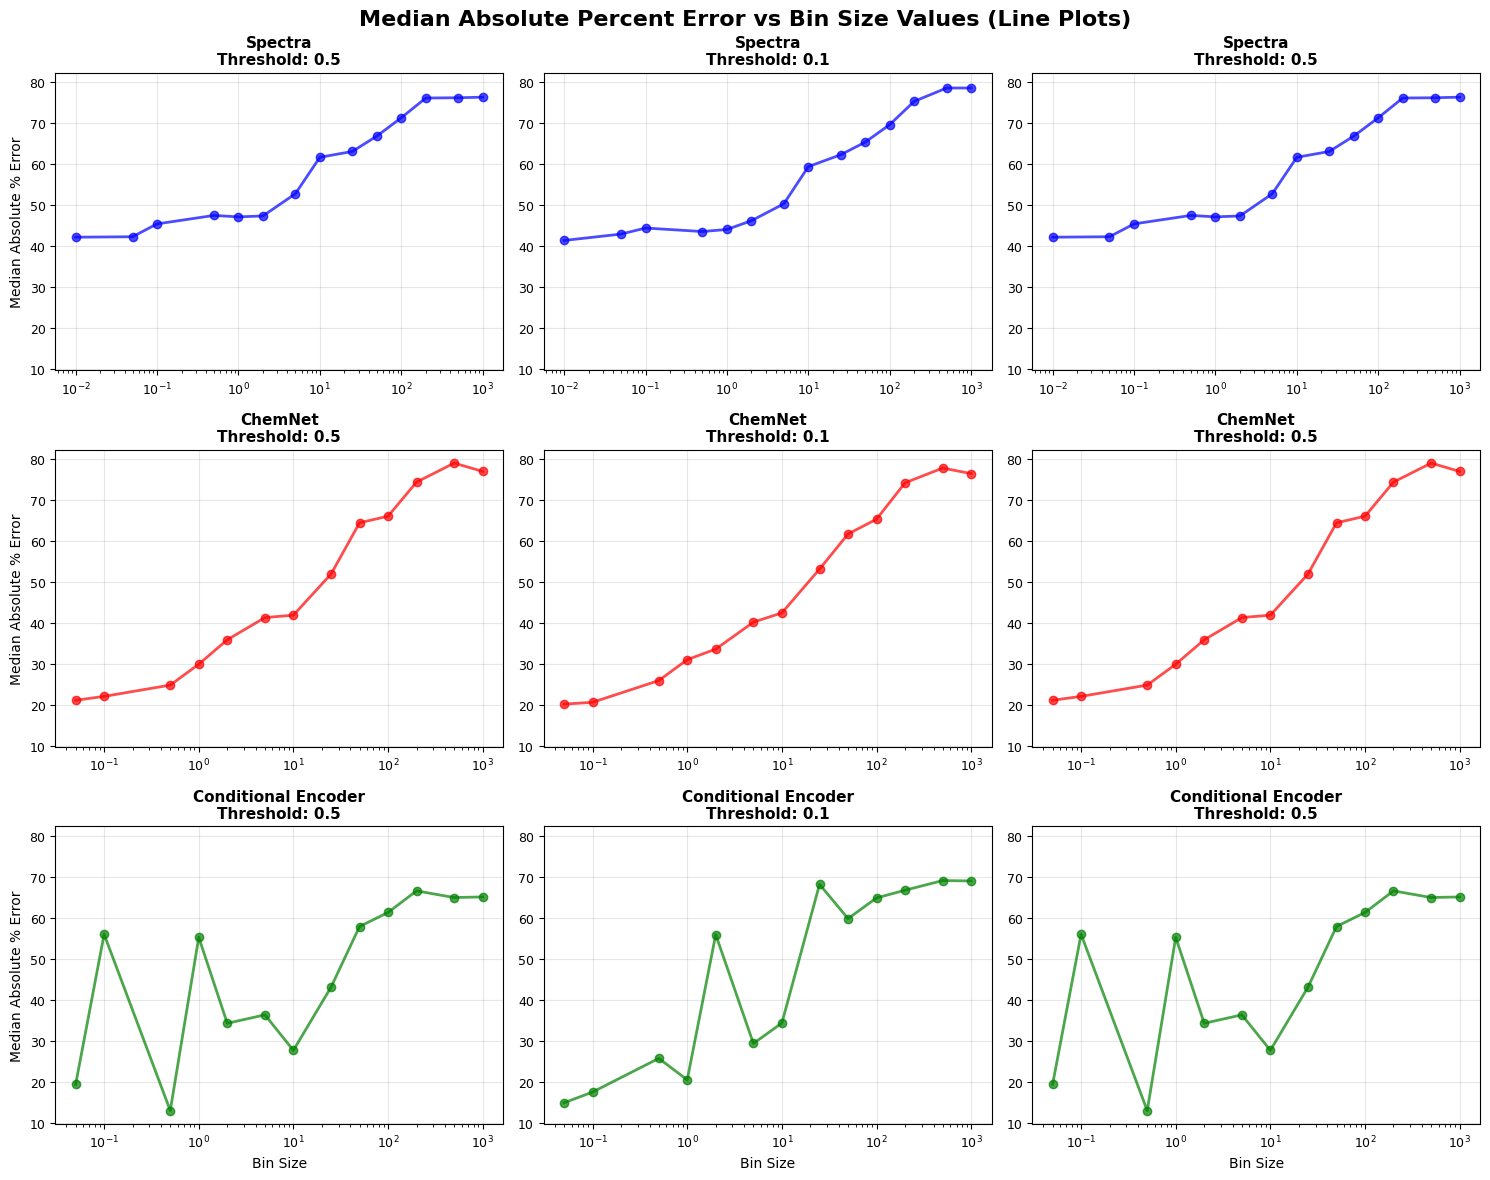

=== LINE PLOTS SUMMARY ===

Spectra:
  Threshold 0.5: 14 data points, min error: 42.2%
  Threshold 0.1: 14 data points, min error: 41.4%
  Threshold 0.5: 14 data points, min error: 42.2%

ChemNet:
  Threshold 0.5: 13 data points, min error: 21.2%
  Threshold 0.1: 13 data points, min error: 20.3%
  Threshold 0.5: 13 data points, min error: 21.2%

Conditional Encoder:
  Threshold 0.5: 13 data points, min error: 13.0%
  Threshold 0.1: 13 data points, min error: 14.9%
  Threshold 0.5: 13 data points, min error: 13.0%


In [25]:
# Configuration - easily changeable threshold values
selected_thresholds = [0.5, 0.10, 0.50]  # Change these values as needed

# Extract data for the selected threshold values
def extract_data_for_thresholds(results_df, thresholds):
    """Extract median percent error data for selected threshold values"""
    data = {}
    for threshold in thresholds:
        threshold_data = results_df[results_df['Threshold'] == threshold].copy()
        if not threshold_data.empty:
            # Sort by bin size for proper line plotting
            threshold_data = threshold_data.sort_values('BinSize')
            data[threshold] = {
                'bin_sizes': threshold_data['BinSize'].values,
                'median_errors': threshold_data['Test_Median_Percent_Error'].values
            }
    return data

# Extract data for all three methods
spectra_data_by_thresh = extract_data_for_thresholds(df_percent_error_results, selected_thresholds)
chemnet_data_by_thresh = extract_data_for_thresholds(df_chemnet_percent_error_results, selected_thresholds)
cond_enc_data_by_thresh = extract_data_for_thresholds(df_cond_percent_error_results, selected_thresholds)

# Calculate global y-axis limits for standardized scale
all_errors = []
data_sources_for_limits = [spectra_data_by_thresh, chemnet_data_by_thresh, cond_enc_data_by_thresh]
for method_data in data_sources_for_limits:
    for threshold_data in method_data.values():
        if 'median_errors' in threshold_data:
            all_errors.extend(threshold_data['median_errors'])

if all_errors:  # Only if we have data
    y_min = min(all_errors)
    y_max = max(all_errors) 
    y_margin = (y_max - y_min) * 0.05  # 5% margin
    y_limits = (y_min - y_margin, y_max + y_margin)
else:
    y_limits = None

# Create 3x3 grid of line plots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Median Absolute Percent Error vs Bin Size Values (Line Plots)', fontsize=16, fontweight='bold')

methods = ['Spectra', 'ChemNet', 'Conditional Encoder']
data_sources = [spectra_data_by_thresh, chemnet_data_by_thresh, cond_enc_data_by_thresh]
colors = ['blue', 'red', 'green']

for method_idx, (method_name, method_data, color) in enumerate(zip(methods, data_sources, colors)):
    for thresh_idx, threshold in enumerate(selected_thresholds):
        ax = axes[method_idx, thresh_idx]
        
        if threshold in method_data:
            bin_sizes = method_data[threshold]['bin_sizes']
            errors = method_data[threshold]['median_errors']
            
            # Plot line with markers
            ax.plot(bin_sizes, errors, marker='o', linewidth=2, markersize=6, 
                   color=color, alpha=0.7, label=f'Threshold {threshold}')
            
            # Add grid
            ax.grid(True, alpha=0.3)
            
            # Set labels
            if method_idx == 2:  # Bottom row
                ax.set_xlabel('Bin Size', fontsize=10)
            if thresh_idx == 0:  # Left column
                ax.set_ylabel('Median Absolute % Error', fontsize=10)
            
            # Set title
            ax.set_title(f'{method_name}\nThreshold: {threshold}', fontsize=11, fontweight='bold')
            
            # Set x-axis to log scale if needed (bin sizes span many orders of magnitude)
            if len(bin_sizes) > 1 and max(bin_sizes) / min(bin_sizes) > 100:
                ax.set_xscale('log')
            
            # Add some styling
            ax.tick_params(axis='both', which='major', labelsize=9)
            
            # Standardize y-axis scale
            if y_limits:
                ax.set_ylim(y_limits)
            
        else:
            # No data available
            ax.text(0.5, 0.5, f'No data for\n{method_name}\nThreshold {threshold}', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=10)
            ax.set_title(f'{method_name}\nThreshold: {threshold}', fontsize=11, fontweight='bold')
            
            # Apply same y-limits to empty plots for consistency
            if y_limits:
                ax.set_ylim(y_limits)

plt.tight_layout()
plt.savefig("/home/dlipsey/MITLincolnLabs/Figures/Median_Error_vs_Bin_Size_Line_Plots_large_thresh")
plt.show()

# Print summary of what was plotted
print("=== LINE PLOTS SUMMARY ===")
for method_name, method_data in zip(methods, data_sources):
    print(f"\n{method_name}:")
    for threshold in selected_thresholds:
        if threshold in method_data:
            n_points = len(method_data[threshold]['bin_sizes'])
            min_error = min(method_data[threshold]['median_errors'])
            print(f"  Threshold {threshold}: {n_points} data points, min error: {min_error:.1f}%")
        else:
            print(f"  Threshold {threshold}: No data available")

# Conditional Encoder ChemNet PCA

In [ ]:
# Bin size and threshold size for conditional encoder
bin_size = '0_05'        # Format like dataset name strings  
threshold = '0_1'        # Ditto
# =====================================================================

# Load the true ChemNet embeddings for SMILES matching
true_chemnet_path = '/home/dlipsey/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQpos_no_repeats.csv'
true_chemnet_df = pd.read_csv(true_chemnet_path)

# Construct conditional encoder dataset name
cond_dataset_name = f'cond_enc_bin{bin_size}_thresh{threshold}_df3_QQpos_spectra'

# Load the conditional encoder dataset from the pickle file
cond_enc_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_outputs"
cond_enc_file_path = os.path.join(cond_enc_folder, f"{cond_dataset_name}.pkl")
cond_enc_data = pd.read_pickle(cond_enc_file_path)

print(f"Loaded conditional encoder dataset: {cond_dataset_name}")
print(f"Shape: {cond_enc_data.shape}")
print(f"Columns: {cond_enc_data.columns.tolist()}")

# Get the conditional encoder embedding columns (exclude SMILES, Response, and other non-embedding columns)
numeric_cols = cond_enc_data.select_dtypes(include=[np.number]).columns.tolist()
# Look for conditional encoder embedding columns - they might be named differently
# Check what columns exist to identify the embedding columns
emb_cols = []
for col in cond_enc_data.columns:
    if 'emb_' in col or 'embed' in col.lower() or (col not in ['SMILES_spectra', 'Response', 'log_response', 'index_id', 'cond_tox_pred']):
        if pd.api.types.is_numeric_dtype(cond_enc_data[col]):
            emb_cols.append(col)

# If we can't find specific embedding columns, use all numeric columns except known non-embedding ones
if len(emb_cols) == 0:
    emb_cols = [col for col in numeric_cols if col not in ['Response', 'log_response', 'index_id', 'cond_tox_pred']]

# Get the true embedding columns to match dimensions
true_emb_cols = [col for col in true_chemnet_df.columns if col != 'SMILES']
n_true_features = len(true_emb_cols)

# Ensure we only use the same number of features as the true embeddings (if needed)
if len(emb_cols) > n_true_features:
    emb_cols_matched = emb_cols[:n_true_features]
else:
    emb_cols_matched = emb_cols

print(f"Conditional encoder embedding columns found: {len(emb_cols)}")
print(f"True embedding columns: {len(true_emb_cols)}")
print(f"Using {len(emb_cols_matched)} matched columns for PCA")

# Get the embedding data
X_cond_enc = cond_enc_data[emb_cols_matched].values

# Create chronic outlier labels using the previously identified chronic outlier IDs
if 'chronic_cond_outlier_ids' in globals():
    # Check if index_id exists in the conditional encoder data
    if 'index_id' in cond_enc_data.columns:
        cond_enc_ids = cond_enc_data['index_id'].tolist()
        is_chronic_outlier = [idx in chronic_cond_outlier_ids for idx in cond_enc_ids]
    else:
        # Use DataFrame index as fallback
        cond_enc_ids = cond_enc_data.index.tolist()
        is_chronic_outlier = [idx in chronic_cond_outlier_ids for idx in cond_enc_ids]
else:
    # If chronic outliers not defined, create dummy data
    print("Warning: chronic_cond_outlier_ids not found, using dummy data")
    is_chronic_outlier = [False] * len(cond_enc_data)

# Perform PCA
pca = PCA(n_components=2)
X_cond_enc_pca = pca.fit_transform(X_cond_enc)

# Find true embeddings by matching SMILES
true_embeddings_pca = []
true_smiles_found = []

for idx, row in cond_enc_data.iterrows():
    smiles = row['SMILES_spectra']
    # Find matching SMILES in true ChemNet data
    true_match = true_chemnet_df[true_chemnet_df['SMILES'] == smiles]
    
    if not true_match.empty:
        # Get the true embedding (exclude SMILES column)
        true_emb_cols = [col for col in true_chemnet_df.columns if col != 'SMILES']
        true_embedding = true_match[true_emb_cols].values[0]
        
        # Ensure dimension matching
        if len(true_embedding) > len(emb_cols_matched):
            true_embedding = true_embedding[:len(emb_cols_matched)]
        
        # Transform the true embedding using the same PCA
        true_embedding_pca = pca.transform(true_embedding.reshape(1, -1))[0]
        true_embeddings_pca.append(true_embedding_pca)
        true_smiles_found.append(smiles)

true_embeddings_pca = np.array(true_embeddings_pca)

In [ ]:
# PLOT 1: Colored by Chronic Outlier Status
plt.figure(figsize=(12, 8))

# Plot non-chronic outliers in blue
non_chronic_mask = ~np.array(is_chronic_outlier)
plt.scatter(X_cond_enc_pca[non_chronic_mask, 0], 
           X_cond_enc_pca[non_chronic_mask, 1],
           c='blue', marker='o', alpha=0.7, s=50, label='Non-chronic outliers')

# Plot chronic outliers in red
chronic_mask = np.array(is_chronic_outlier)
plt.scatter(X_cond_enc_pca[chronic_mask, 0], 
           X_cond_enc_pca[chronic_mask, 1],
           c='red', marker='o', alpha=0.7, s=50, label='Chronic outliers')

# Plot true embeddings as black squares
if len(true_embeddings_pca) > 0:
    plt.scatter(true_embeddings_pca[:, 0], true_embeddings_pca[:, 1], 
               c='black', marker='s', s=25, label=f'True embeddings ({len(true_embeddings_pca)})', 
               linewidth=2)

# Customize the plot
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title(f'2D PCA of Conditional Encoder Embeddings: {cond_dataset_name}\nColored by Chronic Outlier Status')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(f"/home/dlipsey/MITLincolnLabs/Figures/cond_enc_bin{bin_size}_thresh{threshold}_chronic_outlier_PCA.png")
plt.show()